In [1]:
# Importing the requred libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import matplotlib
import matplotlib.pylab as pylab
import math
from math import sqrt
import statsmodels.api as sm

In [3]:
# Ignoring warnings
import warnings
warnings.filterwarnings('ignore')

In [5]:
%matplotlib inline

In [7]:
# SK learn libraries:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import ElasticNet

In [380]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

### Load the dataset

In [11]:
df = pd.read_csv('train.csv')
store = pd.read_csv('store.csv')

In [12]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [13]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


### Analysing the data sets

In [18]:
df.shape

(1017209, 9)

In [20]:
store.shape

(1115, 10)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [23]:
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [26]:
# See the missing values
df.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [28]:
# See the missing values
store.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [30]:
# Statical summary of the data
df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [31]:
# No. Of Stores in the Dataset
df['Store'].nunique()

1115

In [34]:
# StateHoliday value counts
df['StateHoliday'].value_counts()

StateHoliday
0    855087
0    131072
a     20260
b      6690
c      4100
Name: count, dtype: int64

In [36]:
df['SchoolHoliday'].value_counts()

SchoolHoliday
0    835488
1    181721
Name: count, dtype: int64

In [38]:
df['StateHoliday'] = df['StateHoliday'].replace({'0' : 0, 'a' : 1, 'b' : 2, 'c' : 3})

In [39]:
df['StateHoliday'].value_counts()

StateHoliday
0    986159
1     20260
2      6690
3      4100
Name: count, dtype: int64

In [40]:
print('Start date:', df['Date'].min())
print('End date:', df['Date'].max())

Start date: 2013-01-01
End date: 2015-07-31


##### So the data is from 2013-01-01 to 2015-07-31

In [45]:
# extract year, month, day and week of year from "Date"

df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].apply(lambda x: x.year)
df['Month'] = df['Date'].apply(lambda x: x.month)
df['Day'] = df['Date'].apply(lambda x: x.day)
df['WeekOfYear'] = df['Date'].apply(lambda x: x.weekofyear)

In [46]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,WeekOfYear
0,1,5,2015-07-31,5263,555,1,1,0,1,2015,7,31,31
1,2,5,2015-07-31,6064,625,1,1,0,1,2015,7,31,31
2,3,5,2015-07-31,8314,821,1,1,0,1,2015,7,31,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,2015,7,31,31
4,5,5,2015-07-31,4822,559,1,1,0,1,2015,7,31,31


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 13 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[ns]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  int64         
 8   SchoolHoliday  1017209 non-null  int64         
 9   Year           1017209 non-null  int64         
 10  Month          1017209 non-null  int64         
 11  Day            1017209 non-null  int64         
 12  WeekOfYear     1017209 non-null  int64         
dtypes: datetime64[ns](1), int64(12)
memory usage: 100.9 MB


In [48]:
data = pd.merge(df, store, how = "left", on = "Store")

In [49]:
data.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,...,WeekOfYear,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,2015,...,31,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,2015,...,31,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,2015,...,31,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,2015,...,31,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,2015,...,31,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [50]:
# Percentage of null data
data.isnull().sum() * 100 / df.shape[0]

Store                         0.000000
DayOfWeek                     0.000000
Date                          0.000000
Sales                         0.000000
Customers                     0.000000
Open                          0.000000
Promo                         0.000000
StateHoliday                  0.000000
SchoolHoliday                 0.000000
Year                          0.000000
Month                         0.000000
Day                           0.000000
WeekOfYear                    0.000000
StoreType                     0.000000
Assortment                    0.000000
CompetitionDistance           0.259730
CompetitionOpenSinceMonth    31.787764
CompetitionOpenSinceYear     31.787764
Promo2                        0.000000
Promo2SinceWeek              49.943620
Promo2SinceYear              49.943620
PromoInterval                49.943620
dtype: float64

In [51]:
# Columns with less importance
columns_to_drop = ['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']
data.drop(columns=columns_to_drop, inplace = True)

In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 17 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   Store                1017209 non-null  int64         
 1   DayOfWeek            1017209 non-null  int64         
 2   Date                 1017209 non-null  datetime64[ns]
 3   Sales                1017209 non-null  int64         
 4   Customers            1017209 non-null  int64         
 5   Open                 1017209 non-null  int64         
 6   Promo                1017209 non-null  int64         
 7   StateHoliday         1017209 non-null  int64         
 8   SchoolHoliday        1017209 non-null  int64         
 9   Year                 1017209 non-null  int64         
 10  Month                1017209 non-null  int64         
 11  Day                  1017209 non-null  int64         
 12  WeekOfYear           1017209 non-null  int64         
 1

In [53]:
data.isnull().sum()

Store                     0
DayOfWeek                 0
Date                      0
Sales                     0
Customers                 0
Open                      0
Promo                     0
StateHoliday              0
SchoolHoliday             0
Year                      0
Month                     0
Day                       0
WeekOfYear                0
StoreType                 0
Assortment                0
CompetitionDistance    2642
Promo2                    0
dtype: int64

In [63]:
median_distance = data['CompetitionDistance'].median()
data['CompetitionDistance'].fillna(median_distance, inplace=True)

In [65]:
data.isnull().sum()

Store                  0
DayOfWeek              0
Date                   0
Sales                  0
Customers              0
Open                   0
Promo                  0
StateHoliday           0
SchoolHoliday          0
Year                   0
Month                  0
Day                    0
WeekOfYear             0
StoreType              0
Assortment             0
CompetitionDistance    0
Promo2                 0
dtype: int64

In [67]:
# Creating a 'TotalSale' column
data['TotalSales'] = data['Sales'] * data['Customers']

In [69]:
# Calculating average sales per customer and creating a new column 'AvgSalesPerCustomer'
data['AvgSalesPerCustomer'] = data['Sales'] / data['Customers']

In [71]:
data.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,WeekOfYear,CompetitionDistance,Promo2,TotalSales,AvgSalesPerCustomer
count,1.017209e+06,1.017209e+06,1017209,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,844340.000000
mean,5.584297e+02,3.998341e+00,2014-04-11 01:30:42.846061824,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,4.516279e-02,1.786467e-01,2.013832e+03,5.846762e+00,1.570279e+01,2.361551e+01,5.422034e+03,5.005638e-01,5.255367e+06,9.493619
min,1.000000e+00,1.000000e+00,2013-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.013000e+03,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000
25%,2.800000e+02,2.000000e+00,2013-08-17 00:00:00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.013000e+03,3.000000e+00,8.000000e+00,1.100000e+01,7.100000e+02,0.000000e+00,1.579184e+06,7.895563
50%,5.580000e+02,4.000000e+00,2014-04-02 00:00:00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.014000e+03,6.000000e+00,1.600000e+01,2.200000e+01,2.330000e+03,1.000000e+00,3.541440e+06,9.250000
75%,8.380000e+02,6.000000e+00,2014-12-12 00:00:00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,2.014000e+03,8.000000e+00,2.300000e+01,3.500000e+01,6.880000e+03,1.000000e+00,6.464172e+06,10.899729
max,1.115000e+03,7.000000e+00,2015-07-31 00:00:00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,3.000000e+00,1.000000e+00,2.015000e+03,1.200000e+01,3.100000e+01,5.200000e+01,7.586000e+04,1.000000e+00,2.100457e+08,64.957854
std,3.219087e+02,1.997391e+00,NaN,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,2.836559e-01,3.830564e-01,7.773960e-01,3.326097e+00,8.787638e+00,1.443338e+01,7.706913e+03,4.999999e-01,7.306888e+06,2.197494


In [72]:
print('Min sales in a day:', df['Sales'].min())
print('Max sales in a day:', df['Sales'].max())

Min sales in a day: 0
Max sales in a day: 41551


##### Total sales per month

In [76]:
# Group data by 'Month' and calculate the total sales for each month
monthly_sales = data.groupby('Month')['Sales'].sum()
print("Total sales per month:")
monthly_sales

Total sales per month:


Month
1     566728724
2     528734410
3     599831906
4     575895295
5     569248217
6     578112775
7     595059205
8     361791202
9     342570131
10    351878728
11    369498877
12    433831153
Name: Sales, dtype: int64

##### Average sales based on school holiday

In [79]:
avg_sales_school_holiday = data.groupby('SchoolHoliday')['Sales'].mean()
print("Average sales based on school holiday:")
avg_sales_school_holiday

Average sales based on school holiday:


SchoolHoliday
0    5620.979034
1    6476.522207
Name: Sales, dtype: float64

In [81]:
data['StateHoliday'].value_counts()

StateHoliday
0    986159
1     20260
2      6690
3      4100
Name: count, dtype: int64

In [83]:
# Calculate the percentage of open stores on different days of the week
print("Percentage of open stores by day of the week:")
data.groupby('DayOfWeek')['Open'].mean() * 100

Percentage of open stores by day of the week:


DayOfWeek
1    95.045948
2    98.830871
3    97.440016
4    92.319929
5    95.059824
6    99.535687
7     2.482554
Name: Open, dtype: float64

#### Total sales per store

In [86]:
# Calculate the total sales for each store (top 20)
total_sales_per_store = data.groupby('Store')['Sales'].sum().sort_values(ascending=False)
print("Total sales for each store (descending order):")
total_sales_per_store[:20]

Total sales for each store (descending order):


Store
262     19516842
817     17057867
562     16927322
1114    16202585
251     14896870
513     14252406
788     14082141
733     14067158
383     13489879
756     12911782
335     12541731
698     12202270
523     12175995
595     11774982
586     11742401
320     11630218
842     11553523
380     11261676
544     10993709
1033    10870270
Name: Sales, dtype: int64

In [88]:
# Creating a new column 'SalesCategory' based on sales ranges (low, medium, high)
sales_bins = [0, 5000, 10000, float('inf')]
sales_labels = ['Low', 'Medium', 'High']
data['SalesCategory'] = pd.cut(df['Sales'], bins = sales_bins, labels = sales_labels)
print("Sales categories:")
print(data[['Sales', 'SalesCategory']].head())

Sales categories:
   Sales SalesCategory
0   5263        Medium
1   6064        Medium
2   8314        Medium
3  13995          High
4   4822           Low


In [90]:
# Comparing the average sales on promotional days vs non-promotional days
avg_sales_promo = data.groupby('Promo')['Sales'].mean()
print("Average sales on promotional vs. non-promotional days:")
avg_sales_promo

Average sales on promotional vs. non-promotional days:


Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64

In [92]:
# Calculating the average sales on different days of the week
avg_sales_by_day = data.groupby('DayOfWeek')['Sales'].mean()
print("Average sales on each day of the week:")
avg_sales_by_day

Average sales on each day of the week:


DayOfWeek
1    7809.044510
2    7005.244467
3    6555.884138
4    6247.575913
5    6723.274305
6    5847.562599
7     204.183189
Name: Sales, dtype: float64

In [94]:
# Looking into the correlation between 'Sales' and 'Customers'
sales_customers_corr = data['Sales'].corr(data['Customers'])
print("Correlation between Sales and Customers:", sales_customers_corr)

Correlation between Sales and Customers: 0.8947107733016958


In [96]:
# Investigate the relationship between 'Sales' and 'SchoolHoliday'
avg_sales_school_holiday = data.groupby('SchoolHoliday')['Sales'].mean()
print("Average sales on days with and without a school holiday:")
avg_sales_school_holiday

Average sales on days with and without a school holiday:


SchoolHoliday
0    5620.979034
1    6476.522207
Name: Sales, dtype: float64

In [98]:
# Create new columns for each category using one-hot encoding
data['SalesCategory_Medium'] = np.where(data['SalesCategory'] == 'Medium', 1, 0)
data['SalesCategory_Low'] = np.where(data['SalesCategory'] == 'Low', 1, 0)
data['SalesCategory_High'] = np.where(data['SalesCategory'] == 'High', 1, 0)

In [100]:
# Create a pivot table
pivot_table = pd.pivot_table(data,
                             values=['SalesCategory_Medium', 'SalesCategory_Low', 'SalesCategory_High'],
                             index=['SalesCategory'],
                             aggfunc=np.sum,
                             fill_value=0)

# Display the pivot table
print(pivot_table)

               SalesCategory_High  SalesCategory_Low  SalesCategory_Medium
SalesCategory                                                             
Low                             0             230240                     0
Medium                          0                  0                500465
High                       113633                  0                     0


## Performing EDA

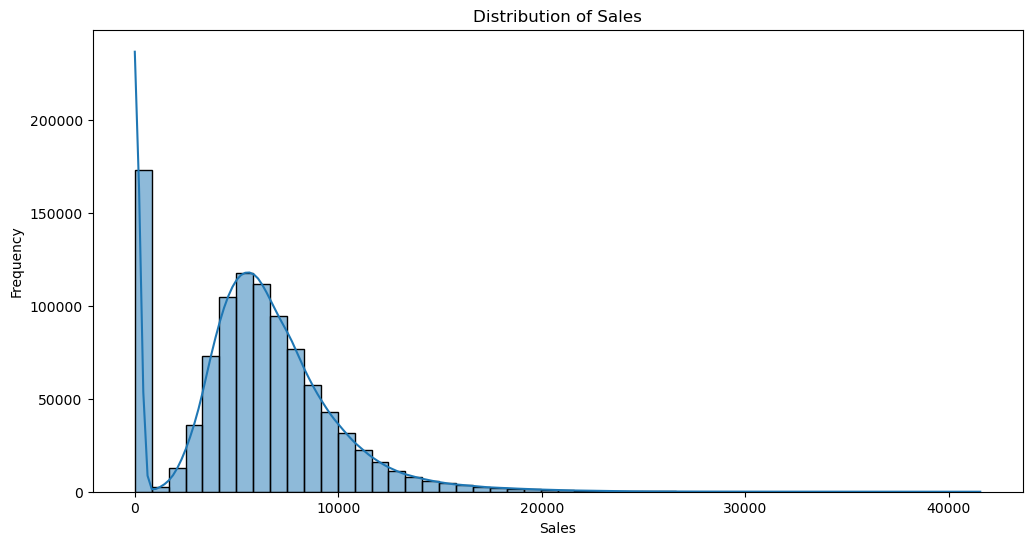

In [103]:
# Sales distribution
plt.figure(figsize = (12, 6))
sns.histplot(data['Sales'], bins = 50, kde = True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

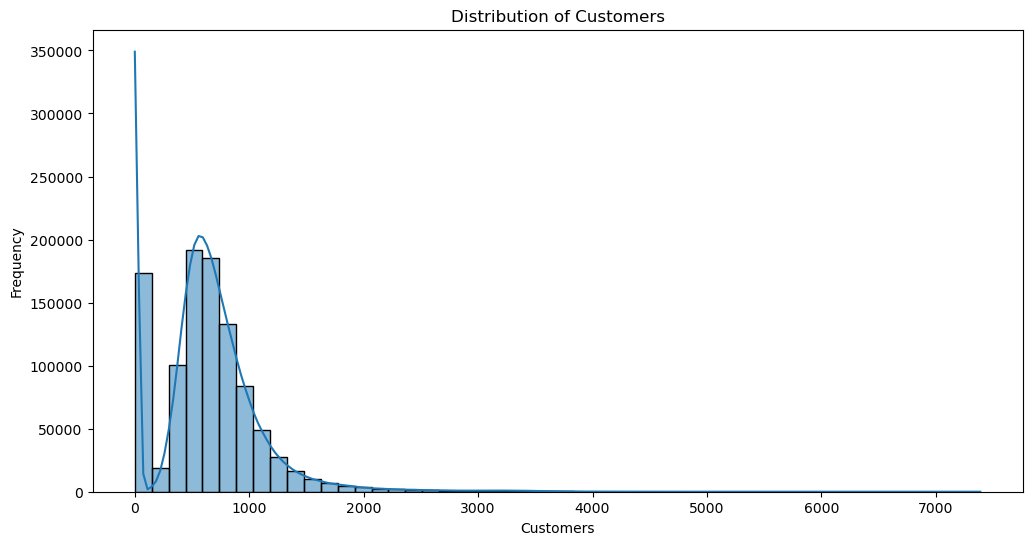

In [104]:
# Customers distribution
plt.figure(figsize = (12, 6))
sns.histplot(data['Customers'], bins = 50, kde = True)
plt.title('Distribution of Customers')
plt.xlabel('Customers')
plt.ylabel('Frequency')
plt.show()

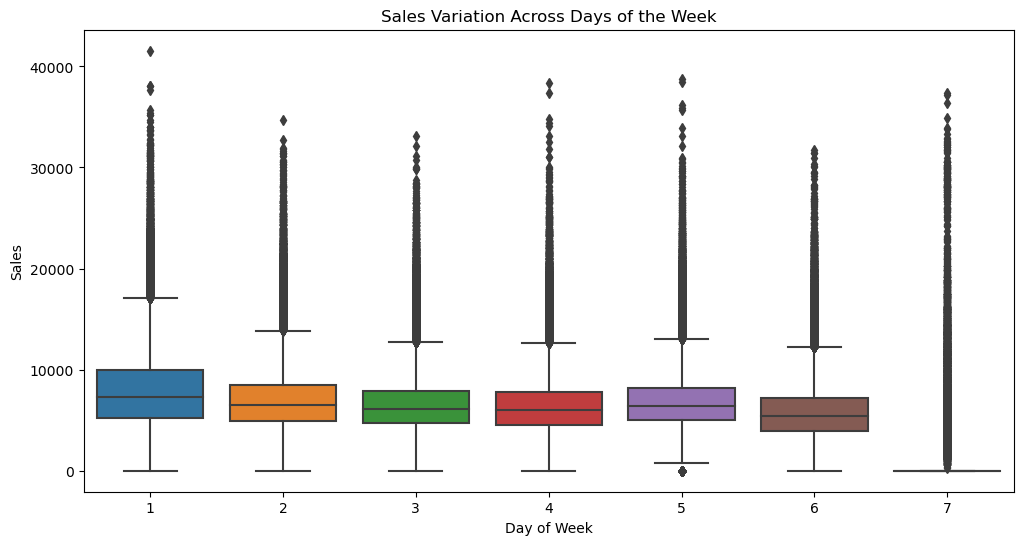

In [105]:
# Sales vs DayOfWeek
plt.figure(figsize=(12, 6))
sns.boxplot(x = 'DayOfWeek', y = 'Sales', data = data)
plt.title('Sales Variation Across Days of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Sales')
plt.show()

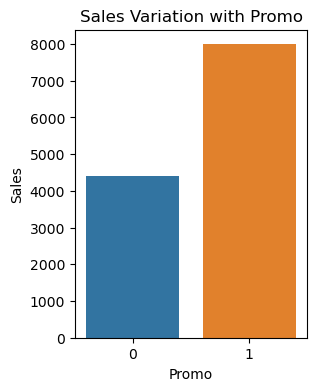

In [106]:
# Sales vs Promo - Bar Plot
plt.figure(figsize=(3, 4))
sns.barplot(x='Promo', y = 'Sales', data = data, ci = None)
plt.title('Sales Variation with Promo')
plt.xlabel('Promo')
plt.ylabel('Sales')
plt.show()

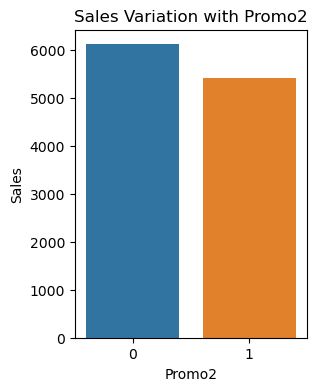

In [107]:
# Sales vs Promo - Bar Plot
plt.figure(figsize=(3, 4))
sns.barplot(x='Promo2', y = 'Sales', data = data, ci = None)
plt.title('Sales Variation with Promo2')
plt.xlabel('Promo2')
plt.ylabel('Sales')
plt.show()

#### Impact on promotion
 - When there is no promotion (promo = 0), the average sales value is around 4500.
 - When there is a promotion (promo = 1), the average sales value is around 8000.
 - Not much impact with Promo2. The column can be deleted.

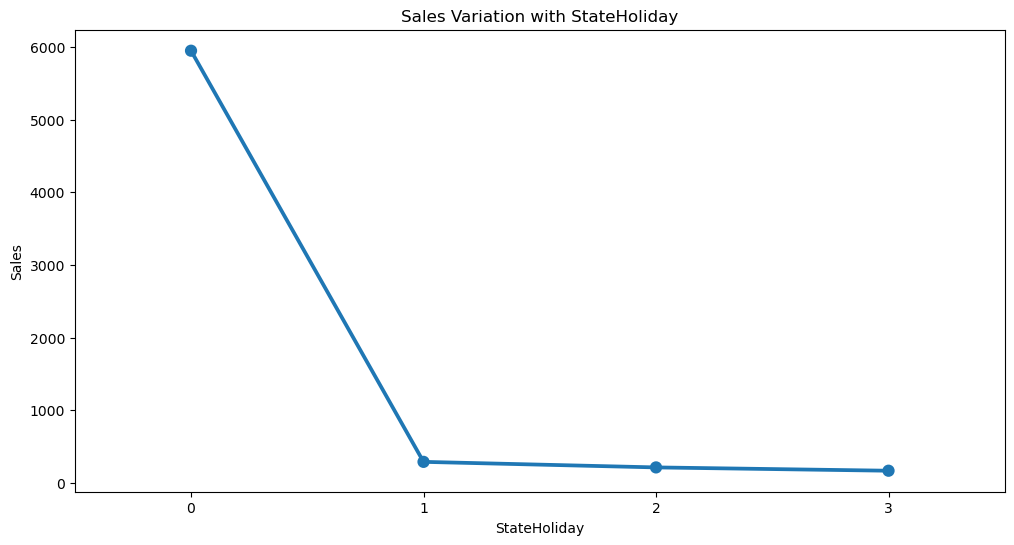

In [109]:
# Sales vs StateHoliday - Point Plot
plt.figure(figsize = (12, 6))
sns.pointplot(x = 'StateHoliday', y = 'Sales', data = data, ci=None)
plt.title('Sales Variation with StateHoliday')
plt.xlabel('StateHoliday')
plt.ylabel('Sales')
plt.show()

In the point plot comparing sales with different state holidays, it appears that state holidays coded as 0 (public holiday) have the highest average sales compared to other categories.

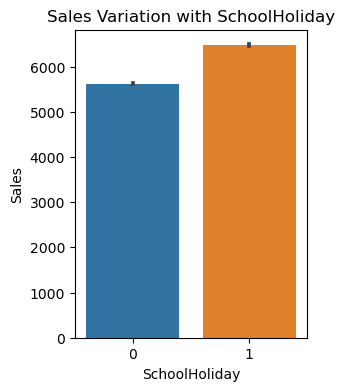

In [111]:
# Sales vs SchoolHoliday
plt.figure(figsize = (3, 4))
sns.barplot(x = 'SchoolHoliday', y = 'Sales', data = data)
plt.title('Sales Variation with SchoolHoliday')
plt.xlabel('SchoolHoliday')
plt.ylabel('Sales')
plt.show()

It appears that during school holidays (coded as '1'), the average sales are slightly higher compared to regular days (coded as '0'). But there are not much difference.

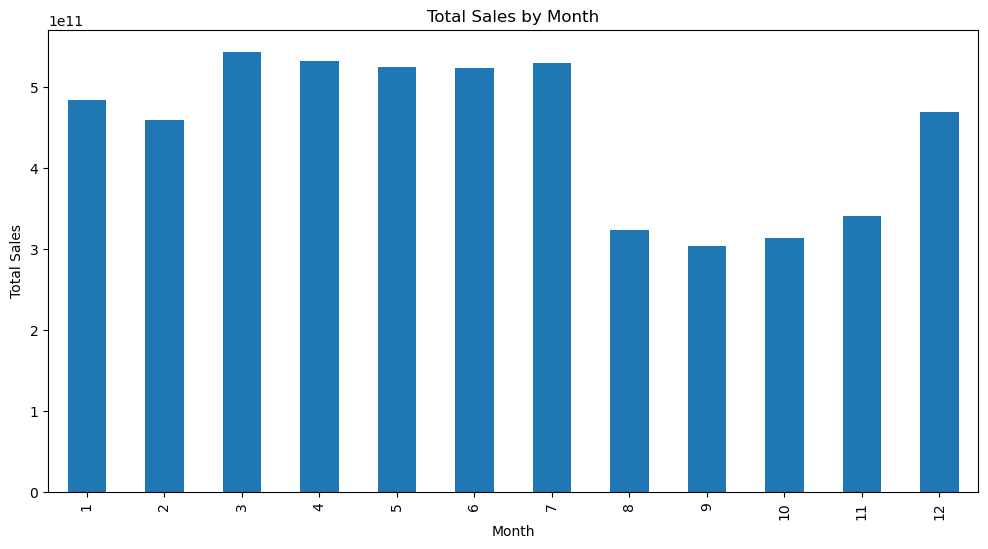

In [113]:
# Total Sales by Month
plt.figure(figsize = (12, 6))
monthly_sales_plot = data.groupby('Month')['TotalSales'].sum().plot(kind = 'bar')
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

Month between March to July has higher totalsales

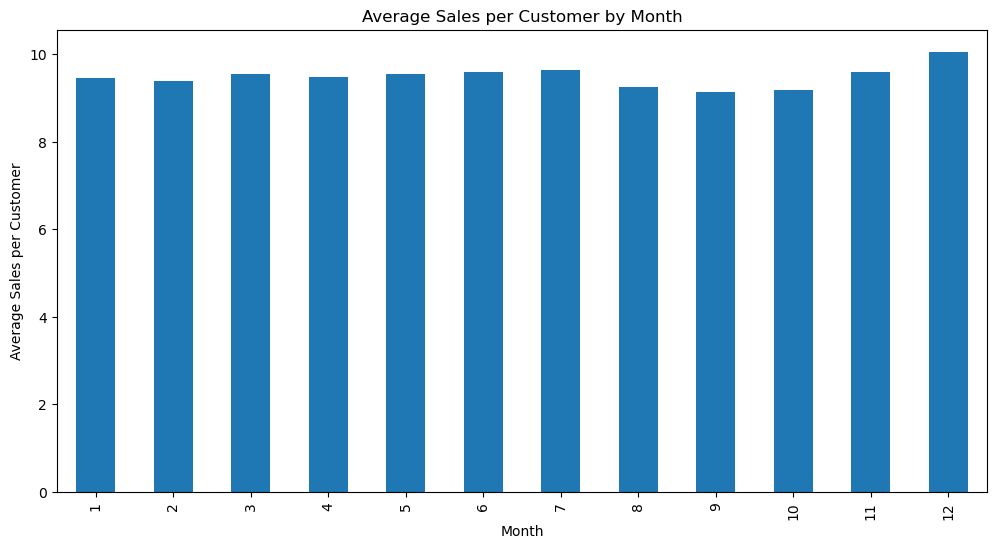

In [115]:
# Average Sales per Customer by Month
plt.figure(figsize = (12, 6))
avg_sales_per_customer_plot = data.groupby('Month')['AvgSalesPerCustomer'].mean().plot(kind = 'bar')
plt.title('Average Sales per Customer by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales per Customer')
plt.show()

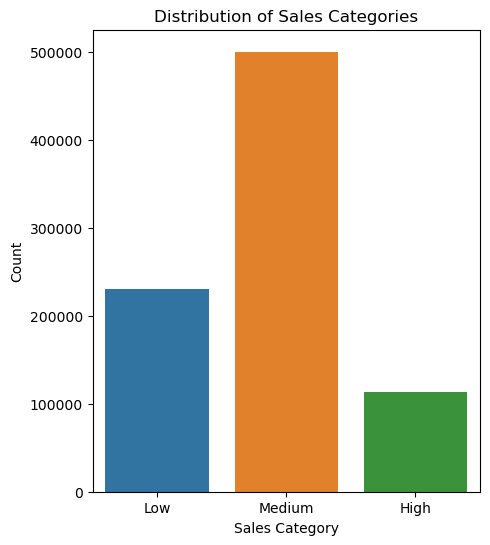

In [116]:
# Sales Category Distribution
plt.figure(figsize = (5, 6))
sns.countplot(x = 'SalesCategory', data = data, order=['Low', 'Medium', 'High'])
plt.title('Distribution of Sales Categories')
plt.xlabel('Sales Category')
plt.ylabel('Count')
plt.show()

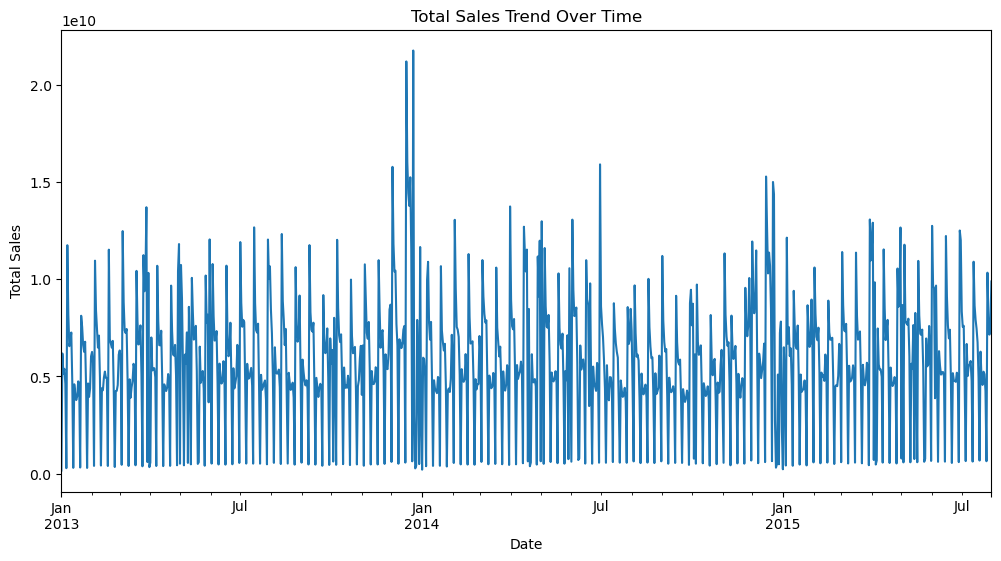

In [117]:
# Total Sales Trend Over Time
plt.figure(figsize = (12, 6))
data.groupby('Date')['TotalSales'].sum().plot()
plt.title('Total Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

Total sales trend are slightly higher in Jan 2014 month

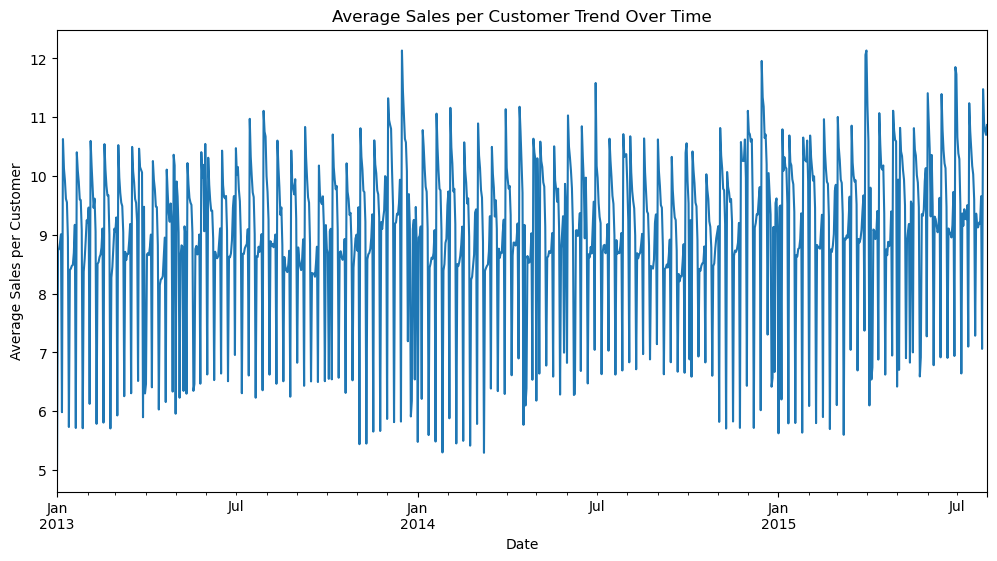

In [119]:
# Average Sales per Customer Trend Over Time
plt.figure(figsize = (12, 6))
data.groupby('Date')['AvgSalesPerCustomer'].mean().plot()
plt.title('Average Sales per Customer Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Average Sales per Customer')
plt.show()

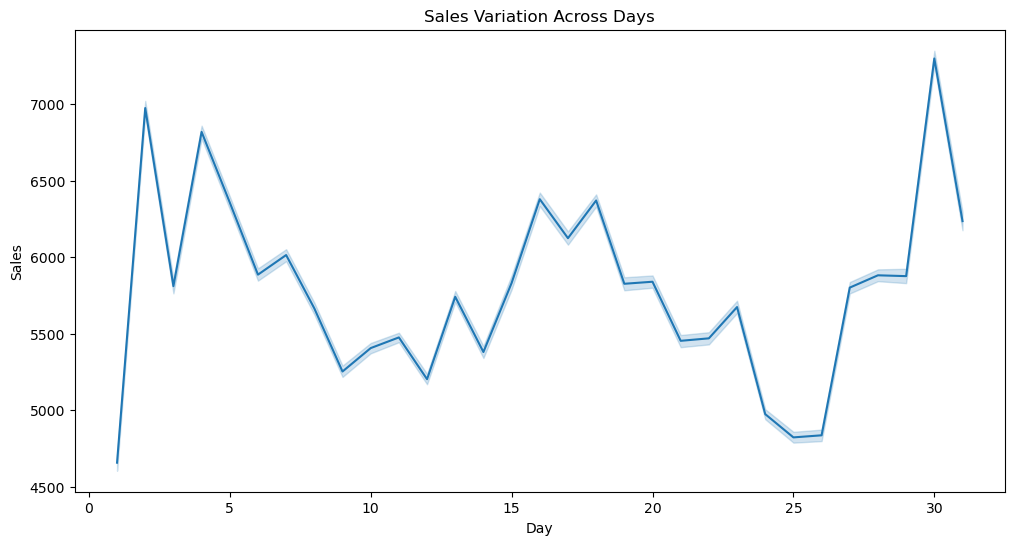

In [132]:
# Sales vs Day
plt.figure(figsize = (12, 6))
sns.lineplot(x = 'Day', y = 'Sales', data = data)
plt.title('Sales Variation Across Days')
plt.xlabel('Day')
plt.ylabel('Sales')
plt.show()

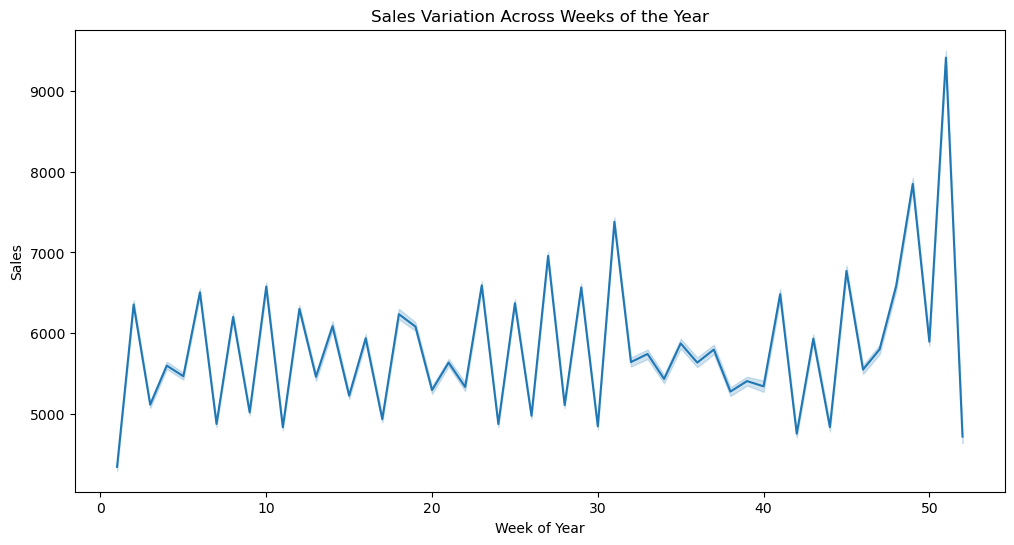

In [133]:
# Sales vs Week of Year
plt.figure(figsize = (12, 6))
sns.lineplot(x = 'WeekOfYear', y = 'Sales', data = data)
plt.title('Sales Variation Across Weeks of the Year')
plt.xlabel('Week of Year')
plt.ylabel('Sales')
plt.show()

End of the year weeks had higher sales

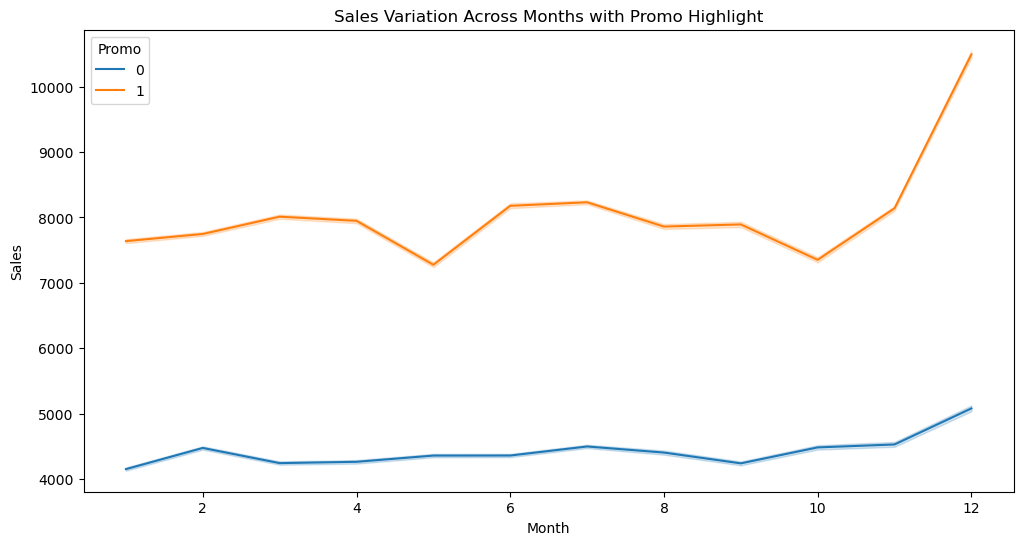

In [137]:
# Sales vs Month with Promo Highlight
plt.figure(figsize = (12, 6))
sns.lineplot(x = 'Month', y = 'Sales', hue = 'Promo', data = data)
plt.title('Sales Variation Across Months with Promo Highlight')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

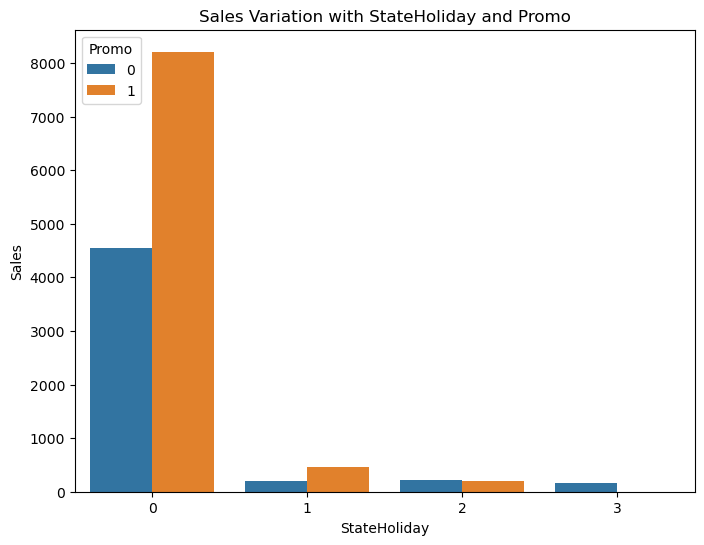

In [139]:
# Barplot of Sales by StateHoliday and Promo
plt.figure(figsize = (8, 6))
sns.barplot(x='StateHoliday', y = 'Sales', hue = 'Promo', data = data, ci = None)
plt.title('Sales Variation with StateHoliday and Promo')
plt.xlabel('StateHoliday')
plt.ylabel('Sales')
plt.show()

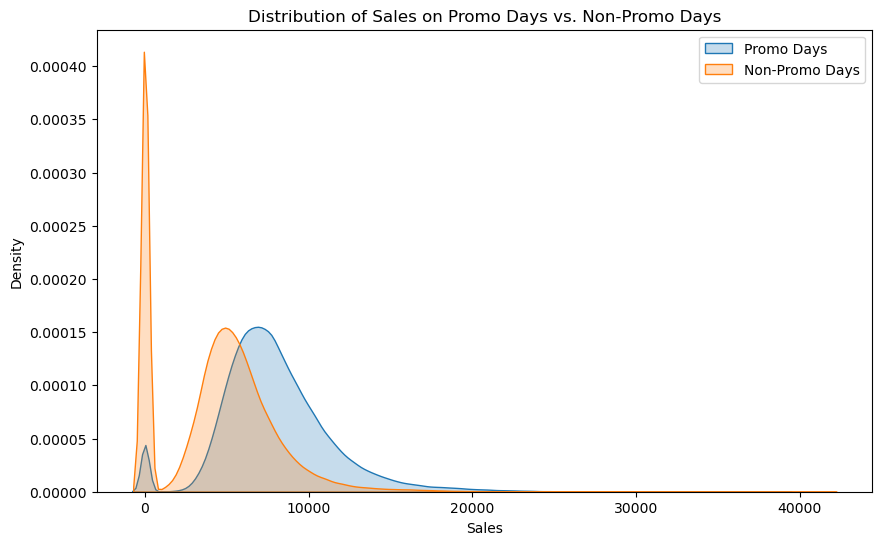

In [141]:
# Distribution of Sales on Promo Days vs. Non-Promo Days
plt.figure(figsize = (10, 6))
sns.kdeplot(data.loc[data['Promo'] == 1, 'Sales'], label = 'Promo Days', shade=True)
sns.kdeplot(data.loc[data['Promo'] == 0, 'Sales'], label = 'Non-Promo Days', shade=True)
plt.title('Distribution of Sales on Promo Days vs. Non-Promo Days')
plt.xlabel('Sales')
plt.ylabel('Density')
plt.legend()
plt.show()

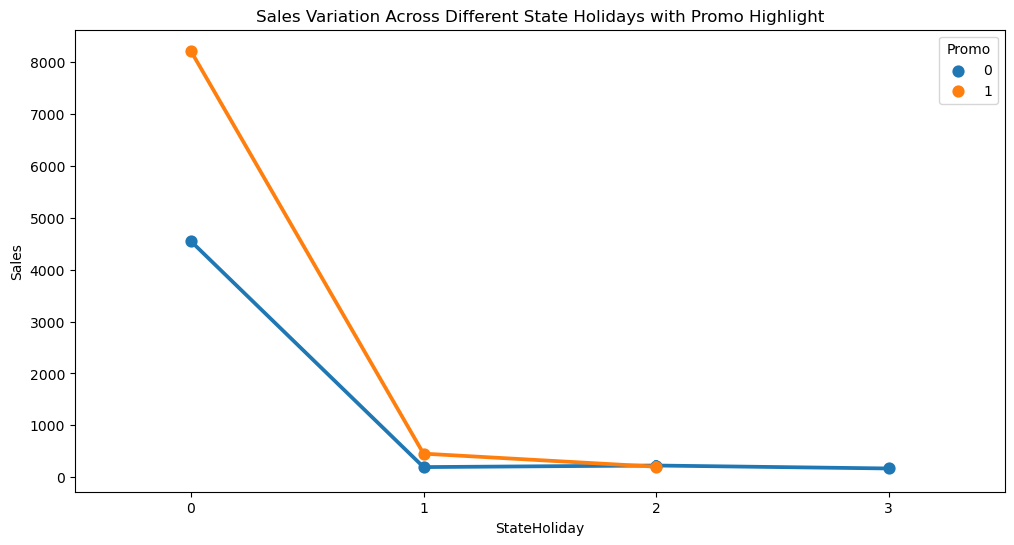

In [143]:
# Sales Variation Across Different State Holidays
plt.figure(figsize = (12, 6))
sns.pointplot(x = 'StateHoliday', y = 'Sales', hue = 'Promo', data = data)
plt.title('Sales Variation Across Different State Holidays with Promo Highlight')
plt.xlabel('StateHoliday')
plt.ylabel('Sales')
plt.show()

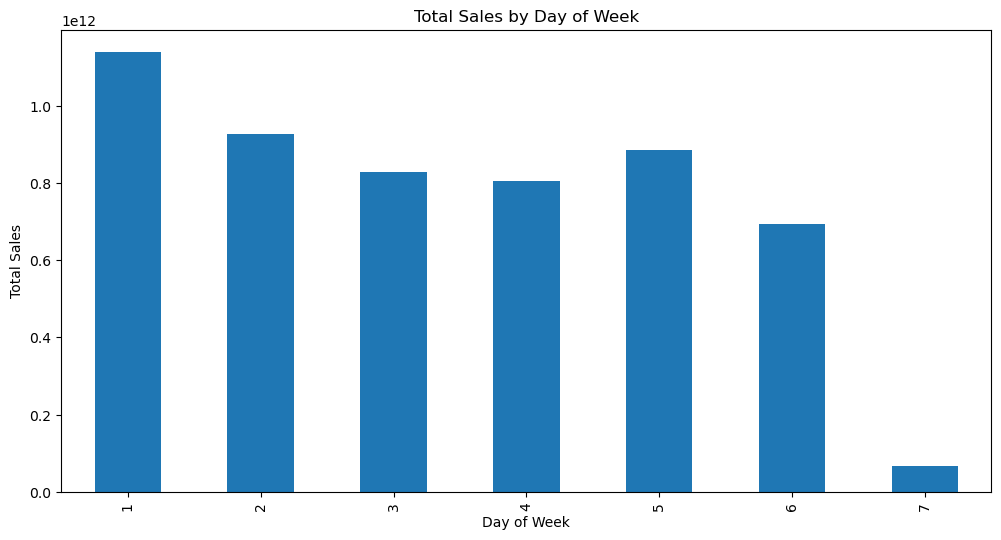

In [144]:
# Total Sales by Day of Week
plt.figure(figsize = (12, 6))
data.groupby('DayOfWeek')['TotalSales'].sum().plot(kind = 'bar')
plt.title('Total Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales')
plt.show()

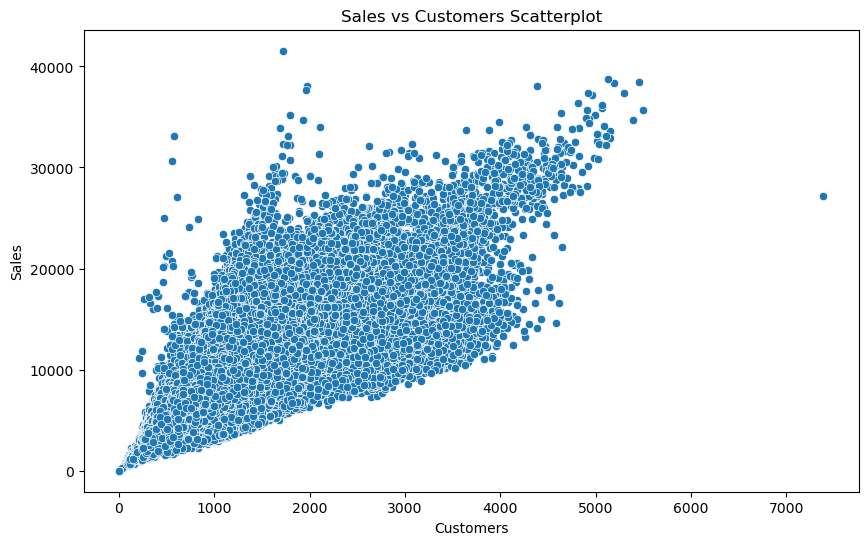

In [145]:
# Sales vs Customers Scatterplot
plt.figure(figsize = (10, 6))
sns.scatterplot(x = 'Customers', y = 'Sales', data = data)
plt.title('Sales vs Customers Scatterplot')
plt.xlabel('Customers')
plt.ylabel('Sales')
plt.show()

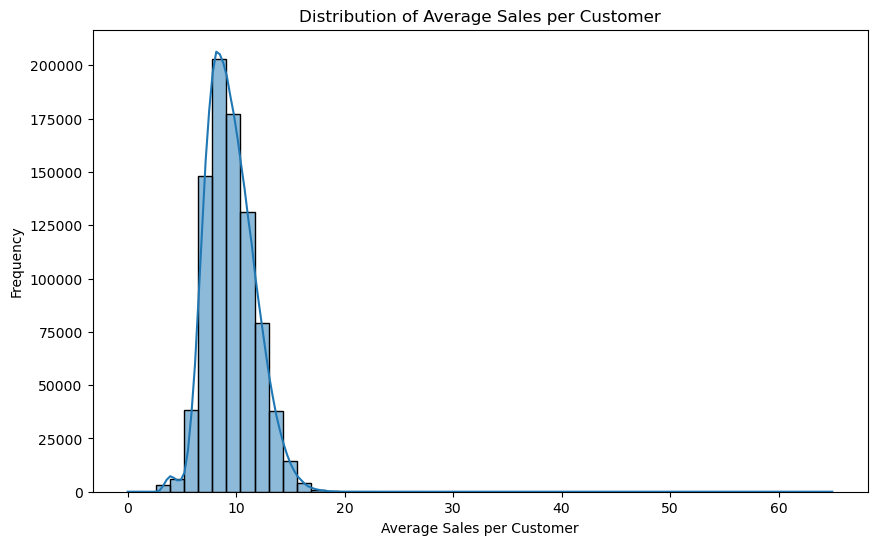

In [146]:
# Distribution of Average Sales per Customer
plt.figure(figsize = (10, 6))
sns.histplot(data['AvgSalesPerCustomer'], bins = 50, kde = True)
plt.title('Distribution of Average Sales per Customer')
plt.xlabel('Average Sales per Customer')
plt.ylabel('Frequency')
plt.show()

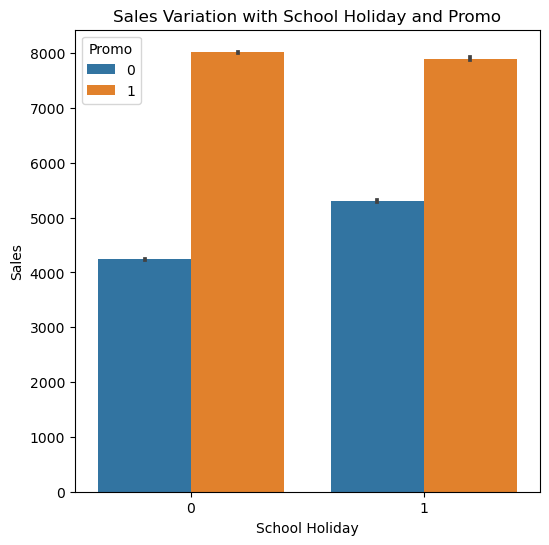

In [147]:
# Boxplot of Sales by School Holiday and Promo
plt.figure(figsize = (6, 6))
sns.barplot(x = 'SchoolHoliday', y = 'Sales', hue = 'Promo', data = data)
plt.title('Sales Variation with School Holiday and Promo')
plt.xlabel('School Holiday')
plt.ylabel('Sales')
plt.show()

In [148]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 23 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   Store                 1017209 non-null  int64         
 1   DayOfWeek             1017209 non-null  int64         
 2   Date                  1017209 non-null  datetime64[ns]
 3   Sales                 1017209 non-null  int64         
 4   Customers             1017209 non-null  int64         
 5   Open                  1017209 non-null  int64         
 6   Promo                 1017209 non-null  int64         
 7   StateHoliday          1017209 non-null  int64         
 8   SchoolHoliday         1017209 non-null  int64         
 9   Year                  1017209 non-null  int64         
 10  Month                 1017209 non-null  int64         
 11  Day                   1017209 non-null  int64         
 12  WeekOfYear            1017209 non-null  in

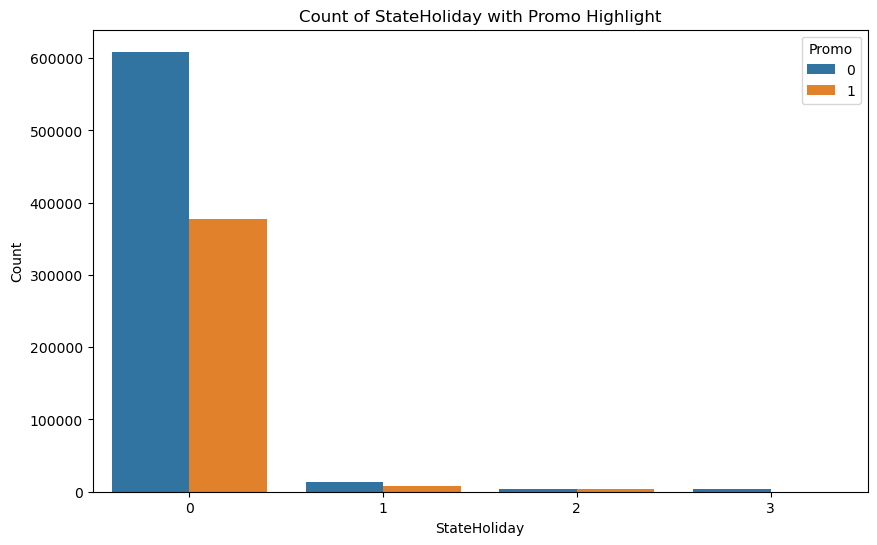

In [155]:
# Countplot of StateHoliday with Promo Highlight
plt.figure(figsize = (10, 6))
sns.countplot(x = 'StateHoliday', hue = 'Promo', data = data)
plt.title('Count of StateHoliday with Promo Highlight')
plt.xlabel('StateHoliday')
plt.ylabel('Count')
plt.show()

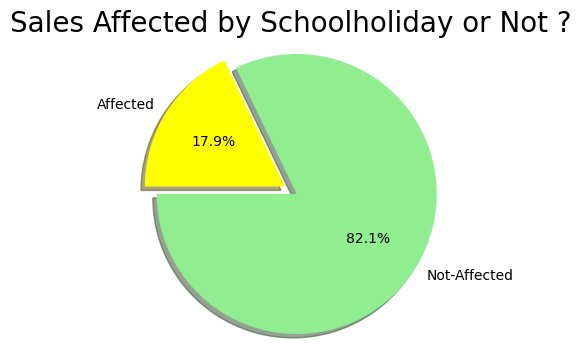

In [157]:
# Sales Affected by Schoolholiday
labels = 'Not-Affected' , 'Affected'
sizes = data.SchoolHoliday.value_counts()
colors = ['lightgreen', 'yellow']
explode = (0.1, 0.0)
plt.pie(sizes, explode = explode, labels = labels, colors = colors,
        autopct = '%1.1f%%', shadow = True, startangle = 180)
plt.axis('equal')
plt.title("Sales Affected by Schoolholiday or Not ?",fontsize=20)
plt.plot()
fig=plt.gcf()
fig.set_size_inches(4, 4)
plt.show()

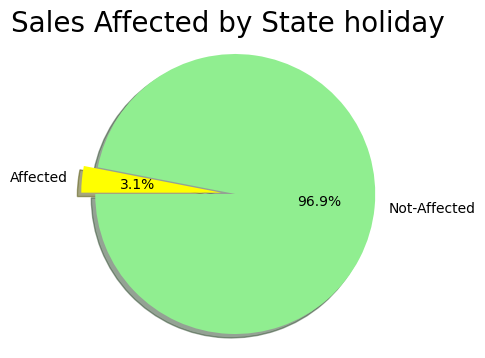

In [159]:
labels = 'Not-Affected' , 'Affected'
data['StateHoliday'] = data['StateHoliday'].replace({0 : 0, 1 : 1, 2 : 1, 3 : 1})
sizes = data.StateHoliday.value_counts()
colors = ['lightgreen', 'yellow']
explode = (0.1, 0.0)
plt.pie(sizes, explode=explode, labels = labels, colors = colors,
        autopct='%1.1f%%', shadow=True, startangle=180)
plt.axis('equal')
plt.title("Sales Affected by State holiday",fontsize=20)
plt.plot()
fig = plt.gcf()
fig.set_size_inches(4,4)
plt.show()

##### There is not much impact fon Sales by State Holiday. Hence dropping the column

In [162]:
data.drop('StateHoliday', inplace = True, axis = 1)

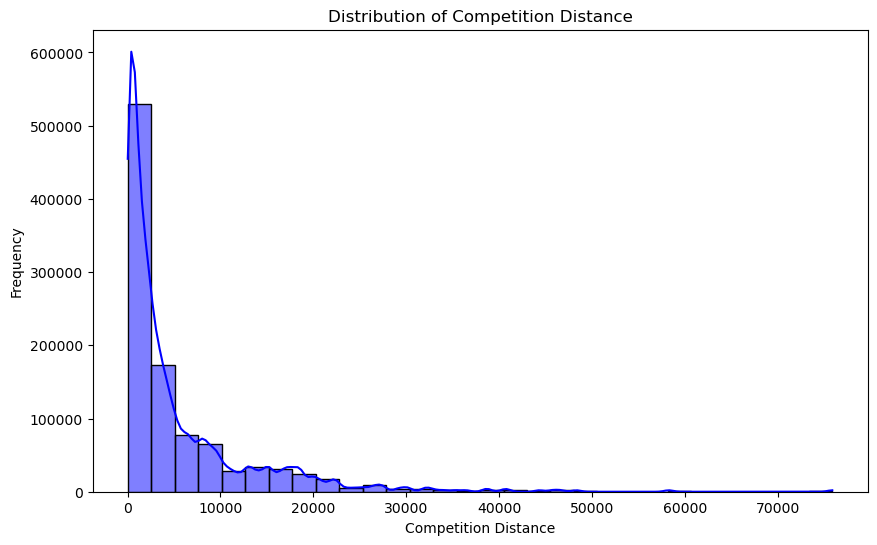

In [165]:
# Distribution of Competition Distance
plt.figure(figsize = (10, 6))
sns.histplot(data['CompetitionDistance'].dropna(), bins = 30, kde = True, color = 'blue')
plt.title('Distribution of Competition Distance')
plt.xlabel('Competition Distance')
plt.ylabel('Frequency')
plt.show()

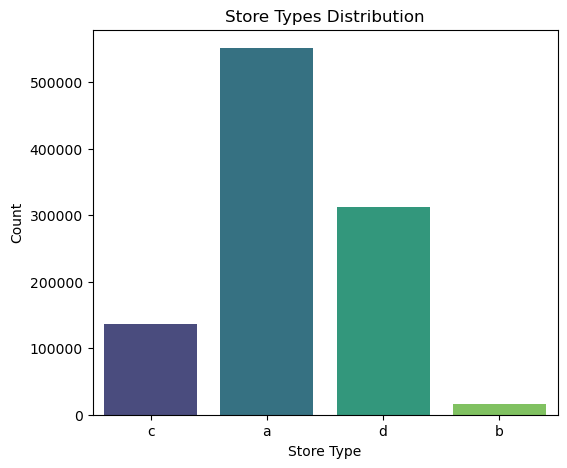

In [166]:
# PLot 34: Store Types Distribution
plt.figure(figsize=(6, 5))
sns.countplot(x = 'StoreType', data = data, palette = 'viridis')
plt.title('Store Types Distribution')
plt.xlabel('Store Type')
plt.ylabel('Count')
plt.show()

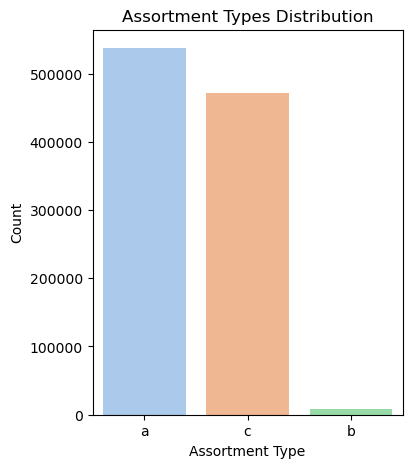

In [167]:
# Plot 35: Assortment Types Distribution
plt.figure(figsize=(4, 5))
sns.countplot(x = 'Assortment', data = data, palette = 'pastel')
plt.title('Assortment Types Distribution')
plt.xlabel('Assortment Type')
plt.ylabel('Count')
plt.show()

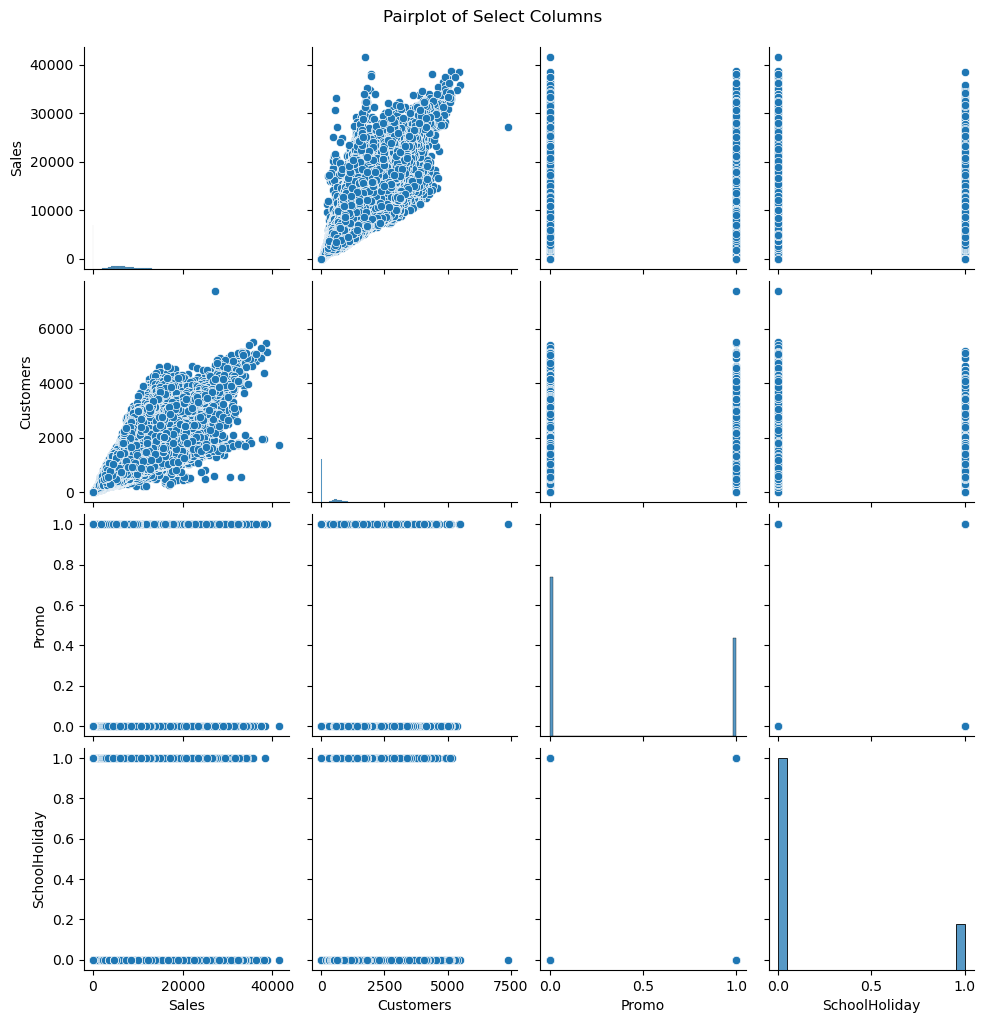

In [168]:
# Pairplot of Select Columns
sns.pairplot(data[['Sales', 'Customers', 'Promo', 'SchoolHoliday']])
plt.suptitle('Pairplot of Select Columns', y = 1.02)
plt.show()

In [169]:
data.StoreType.value_counts()

StoreType
a    551627
d    312912
c    136840
b     15830
Name: count, dtype: int64

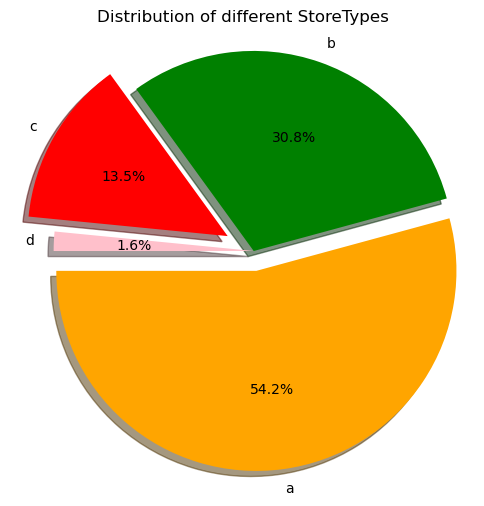

In [171]:
# Distribution of different store trypes
labels = 'a' , 'b' , 'c' , 'd'
sizes = data.StoreType.value_counts()
colors = ['orange', 'green' , 'red' , 'pink']
explode = (0.1, 0.0 , 0.15 , 0.0)
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=180)
plt.axis('equal')
plt.title("Distribution of different StoreTypes")
plt.plot()
fig=plt.gcf()
fig.set_size_inches(6,6)
plt.show()

<Axes: >

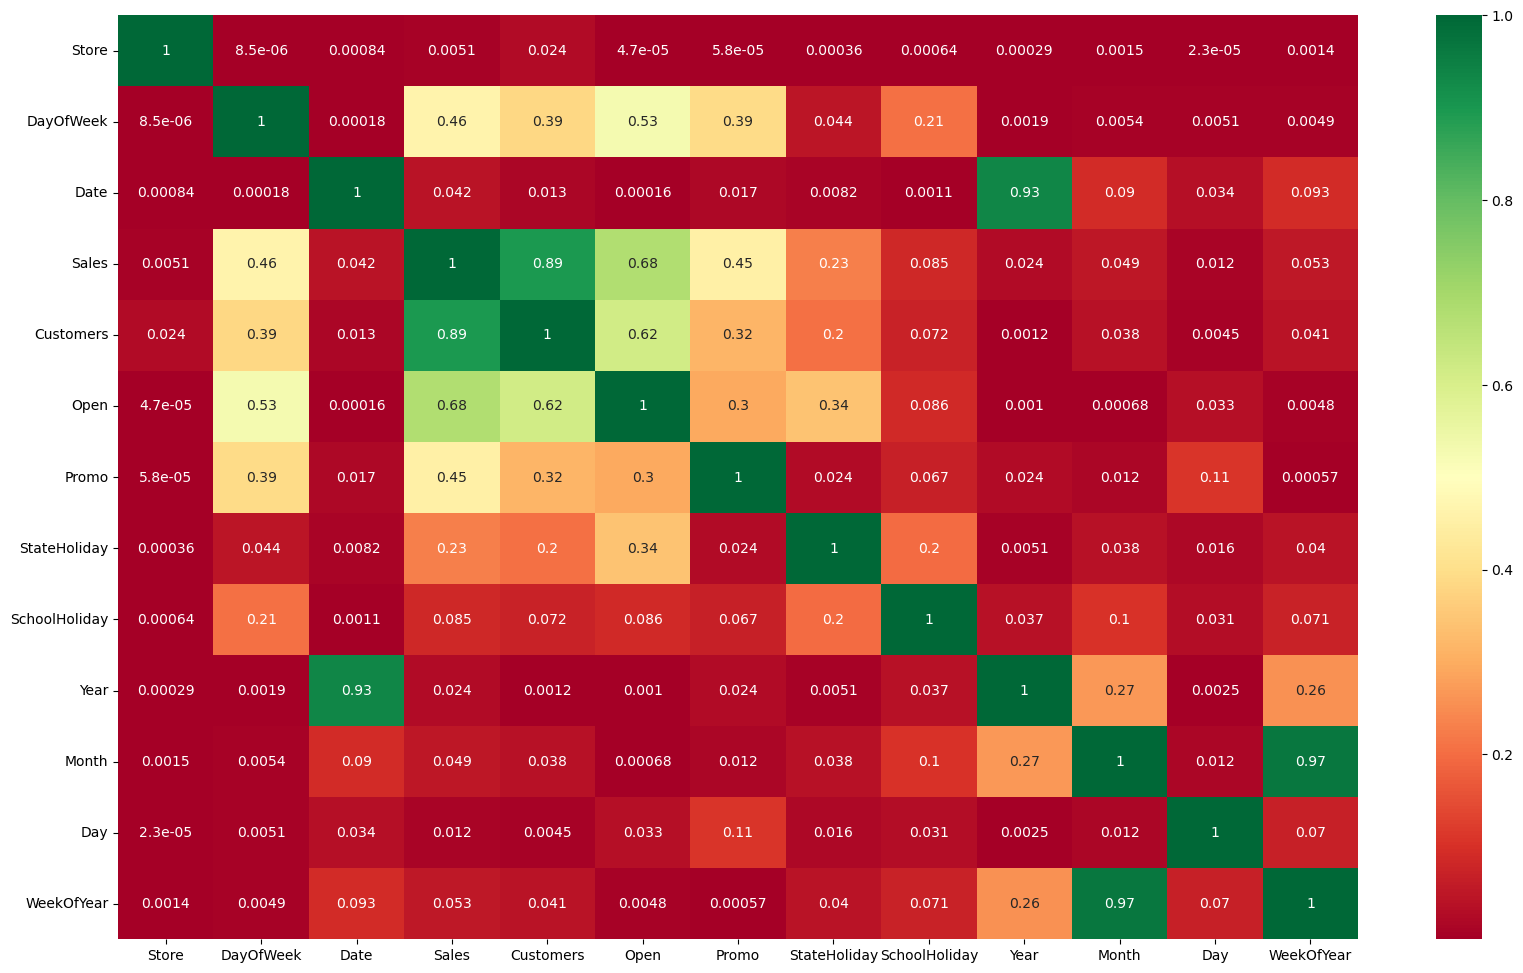

In [174]:
# Correlation with Heatmap
plt.subplots(figsize = (20,12))
sns.heatmap(df.corr().abs(), annot=True, cmap="RdYlGn")

In [175]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 22 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   Store                 1017209 non-null  int64         
 1   DayOfWeek             1017209 non-null  int64         
 2   Date                  1017209 non-null  datetime64[ns]
 3   Sales                 1017209 non-null  int64         
 4   Customers             1017209 non-null  int64         
 5   Open                  1017209 non-null  int64         
 6   Promo                 1017209 non-null  int64         
 7   SchoolHoliday         1017209 non-null  int64         
 8   Year                  1017209 non-null  int64         
 9   Month                 1017209 non-null  int64         
 10  Day                   1017209 non-null  int64         
 11  WeekOfYear            1017209 non-null  int64         
 12  StoreType             1017209 non-null  ob

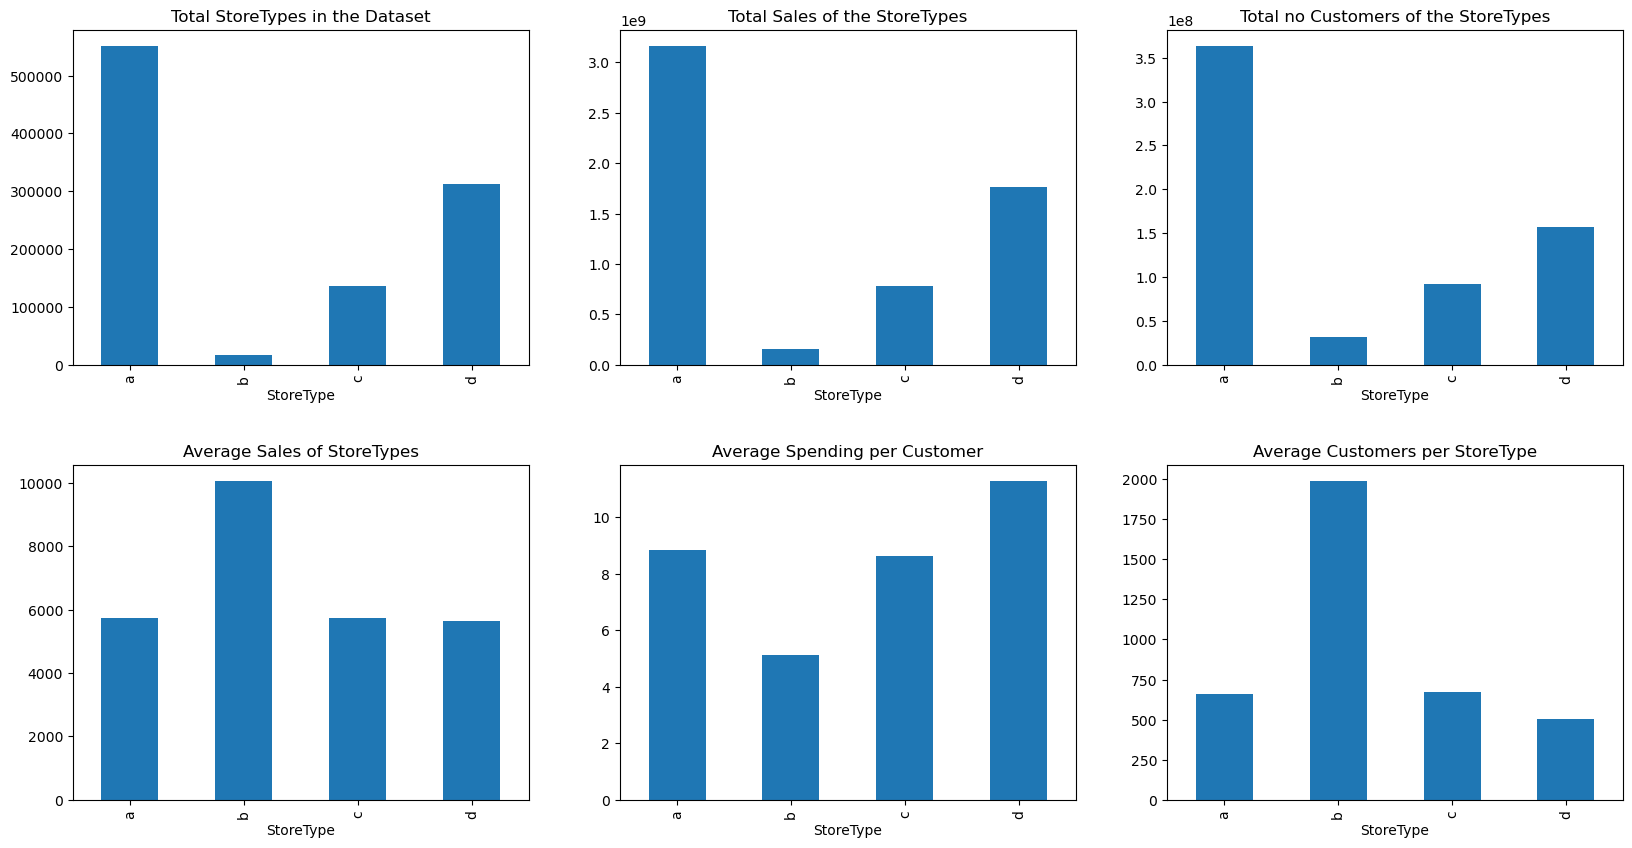

In [176]:
f, ax = plt.subplots(2, 3, figsize = (20,10))

data.groupby("StoreType")["Store"].count().plot(kind = "bar", ax = ax[0, 0], title = "Total StoreTypes in the Dataset")
data.groupby("StoreType")["Sales"].sum().plot(kind = "bar", ax = ax[0,1], title = "Total Sales of the StoreTypes")
data.groupby("StoreType")["Customers"].sum().plot(kind = "bar", ax = ax[0,2], title = "Total no Customers of the StoreTypes")
data.groupby("StoreType")["Sales"].mean().plot(kind = "bar", ax = ax[1,0], title = "Average Sales of StoreTypes")
data.groupby("StoreType")["AvgSalesPerCustomer"].mean().plot(kind = "bar", ax = ax[1,1], title = "Average Spending per Customer")
data.groupby("StoreType")["Customers"].mean().plot(kind = "bar", ax = ax[1,2], title = "Average Customers per StoreType")

plt.subplots_adjust(hspace = 0.3)
plt.show()

#### Observation from the above graphs:
 - The StoreType A has the most stores, sales and customers.
 - StoreType D has the best averages spendings per customers.
 - StoreType B, with only 17 stores has the most average customers and average sales.

### EDA Conclusions:
 - Sales are highly correlated to number of Customers
 - Promotion leads to increase in Sales and Customers both.
 - Sales are increased during Chirstmas week, this might be due to the fact that people buy more products during a Christmas celebration.
 - The store A has most customers and sales
 - StoreType B has the lowest Average Sales per Customer

In [185]:
columnsToDelete = ['Date', 'Store', 'Promo2', 'SalesCategory_High', 'SalesCategory_Medium', 'SalesCategory_Low', 'AvgSalesPerCustomer', 'Assortment']
data.drop(columns = columnsToDelete, axis = 1, inplace= True)

In [187]:
data = pd.get_dummies(data, columns = ['StoreType', 'SalesCategory'])

In [189]:
data.isnull().sum()

DayOfWeek               0
Sales                   0
Customers               0
Open                    0
Promo                   0
SchoolHoliday           0
Year                    0
Month                   0
Day                     0
WeekOfYear              0
CompetitionDistance     0
TotalSales              0
StoreType_a             0
StoreType_b             0
StoreType_c             0
StoreType_d             0
SalesCategory_Low       0
SalesCategory_Medium    0
SalesCategory_High      0
dtype: int64

### Setting Features and Target Variables

In [192]:
X = data.drop(['Sales'] , axis = 1)
y = data.Sales

In [194]:
X.shape

(1017209, 18)

In [196]:
X.head()

,DayOfWeek,Customers,Open,Promo,SchoolHoliday,Year,Month,Day,WeekOfYear,CompetitionDistance,TotalSales,StoreType_a,StoreType_b,StoreType_c,StoreType_d,SalesCategory_Low,SalesCategory_Medium,SalesCategory_High
0,5,555,1,1,1,2015,7,31,31,1270.0,2920965,False,False,True,False,False,True,False
1,5,625,1,1,1,2015,7,31,31,570.0,3790000,True,False,False,False,False,True,False
2,5,821,1,1,1,2015,7,31,31,14130.0,6825794,True,False,False,False,False,True,False
3,5,1498,1,1,1,2015,7,31,31,620.0,20964510,False,False,True,False,False,False,True
4,5,559,1,1,1,2015,7,31,31,29910.0,2695498,True,False,False,False,True,False,False


In [198]:
y.shape

(1017209,)

In [200]:
y.head()

0     5263
1     6064
2     8314
3    13995
4     4822
Name: Sales, dtype: int64

In [202]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

In [204]:
# Transforming data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Creating function to get the Evaluation metrics

In [207]:
def getEvaluationMatrix(model_name, operation_type, y, y_pred):
    print('Evaluation metrics for', model_name, operation_type)

    #calculate MSE
    MSE_linear_train = mean_squared_error(y, y_pred)
    print("MSE :", MSE_linear_train)
    
    #calculate RMSE
    RMSE_linear_train = np.sqrt(MSE_linear_train)
    print("RMSE :", RMSE_linear_train)
    
    #calculate MAE
    MAE_linear_train = mean_absolute_error(y, y_pred)
    print("MAE :", MAE_linear_train)
    
    #calculate r2 and adjusted r2
    R2_linear_train = r2_score(y, y_pred)
    print("R2 :", R2_linear_train)
    
    Adjusted_R2_linear_train = (1 - (1 - r2_score(y_train, y_pred_train)) * ((X_test.shape[0] - 1) / (X_test.shape[0] - X_test.shape[1] - 1)) )
    print("Adjusted R2 :", Adjusted_R2_linear_train)

## 1. Linear Regression (OLS)

In [210]:
# Fitting Multiple Linear Regression to the Training set
linerRegression = LinearRegression()
linerRegression.fit(X_train, y_train)

LinearRegression()

In [212]:
linerRegression.intercept_

2100758922616342.8

In [214]:
linerRegression.coef_

array([-1.72021875e+02,  4.15192301e+03,  1.49204548e+01,  5.16521514e+02,
        6.33478036e+00,  1.18387227e+02,  1.55258325e+02,  2.50710805e+01,
        3.77042476e-01,  5.02073812e+02,  4.62749859e+04, -2.10075892e+15,
       -2.10075892e+15, -2.10075892e+15, -2.10075892e+15,  3.12726743e+03,
        5.08144158e+03,  7.54160825e+03])

In [216]:
y_pred_train = linerRegression.predict(X_train)

In [228]:
# Predicting the Test set results
y_pred_test = linerRegression.predict(X_test)

In [230]:
mean_squared_error(y_test, y_pred_test)

698387.6770645933

In [232]:
# Test performance
math.sqrt(mean_squared_error(y_test, y_pred_test))

835.6959238051801

In [226]:
getEvaluationMatrix('Linear Regression', 'Training', y_train, y_pred_train)

Evaluation metrics for Linear Regression Training
MSE : 704251.8983978914
RMSE : 839.1971749224919
MAE : 610.501424767501
R2 : 0.9525839910348599
Adjusted R2 : 0.9525811940335708


In [234]:
getEvaluationMatrix('Linear Regression', 'Training', y_test, y_pred_test)

Evaluation metrics for Linear Regression Training
MSE : 698387.6770645933
RMSE : 835.6959238051801
MAE : 609.5628082369094
R2 : 0.9526525646980185
Adjusted R2 : 0.9525811940335708


In [236]:
# Training score
linerRegression.score(X_train, y_train)

0.9525839910348599

In [238]:
# Testing score
linerRegression.score(X_test, y_test)

0.9526525646980185

In [240]:
#storing 100 observations for analysis
simple_lr_pred = y_pred[:250]
simple_lr_real = y_test[:250]
dataset_lr = pd.DataFrame({'Real':simple_lr_real,'PredictedLR':simple_lr_pred})

In [242]:
#storing absolute diffrences between actual sales price and predicted
dataset_lr['diff']=(dataset_lr['Real']-dataset_lr['PredictedLR']).abs()

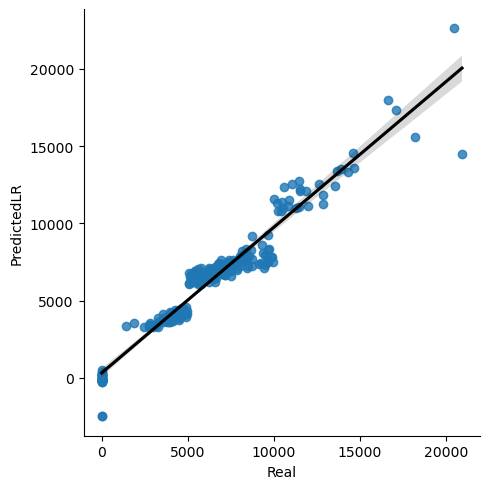

In [244]:
#visualising our predictions
sns.lmplot(x='Real', y='PredictedLR', data=dataset_lr, line_kws={'color': 'black'});

In [246]:
X = sm.add_constant(X)
model = sm.OLS(y, X.astype(float)).fit()
predictions = model.predict(X)

# Print out the statistics
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.953
Model:                            OLS   Adj. R-squared:                  0.953
Method:                 Least Squares   F-statistic:                 1.203e+06
Date:                Sat, 12 Apr 2025   Prob (F-statistic):               0.00
Time:                        00:28:53   Log-Likelihood:            -8.2904e+06
No. Observations:             1017209   AIC:                         1.658e+07
Df Residuals:                 1017191   BIC:                         1.658e+07
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -9.693e+04   1794.119    -54.025      0.000      -1e+05   -9.34e+04
DayOfWeek              -28.5181      0.523    -54.492      0.000     -29.544     -27.492
Customers                0.5599      0.008     73.702      0.000       0.545       0.575
Open                   -10.3841    114.085     -0.091      0.927    -233.987     213.218
Promo                  516.4812      2.021    255.592      0.000     512.521     520.442
SchoolHoliday            4.6159      2.249      2.052      0.040       0.208       9.024
Year                    59.8703      1.113     53.773      0.000      57.688      62.053
Month                   15.1793      1.023     14.836      0.000      13.174      17.185
Day                      0.7714      0.098      7.850      0.000       0.579       0.964
WeekOfYear              -0.2749      0.235     -1.171      0.242      -0.735       0.185
CompetitionDistance      0.0066      0.000     59.411      0.000       0.006       0.007
TotalSales               0.0002   3.57e-07    619.556      0.000       0.000       0.000
StoreType_a          -2.373e+04    448.502    -52.917      0.000   -2.46e+04   -2.29e+04
StoreType_b           -2.61e+04    448.708    -58.161      0.000    -2.7e+04   -2.52e+04
StoreType_c          -2.372e+04    448.512    -52.895      0.000   -2.46e+04   -2.28e+04
StoreType_d          -2.337e+04    448.458    -52.119      0.000   -2.43e+04   -2.25e+04
SalesCategory_Low     3153.5812    114.119     27.634      0.000    2929.912    3377.250
SalesCategory_Medium  5103.4073    114.157     44.705      0.000    4879.664    5327.151
SalesCategory_High    7553.3023    114.245     66.115      0.000    7329.387    7777.218
==============================================================================
Omnibus:                   188873.475   Durbin-Watson:                   1.906
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          4937375.966
Skew:                           0.171   Prob(JB):                         0.00
Kurtosis:                      13.788   Cond. No.                     2.44e+21
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.38e-23. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

## Decision Tree

In [250]:
# Fit Model
decisionTree = DecisionTreeRegressor(max_depth = 50 ,max_features = 20, max_leaf_nodes = 200, random_state = 0)
decisionTree = decisionTree.fit(X_train, y_train)

In [252]:
#Predict train & test values
y_pred_train_dt = decisionTree.predict(X_train)
y_pred_train_dt

array([5.74280262e+03, 6.83762094e-01, 6.83762094e-01, ...,
       7.18769225e+03, 2.73662295e+03, 5.29674701e+03])

In [254]:
y_pred_test_dt = decisionTree.predict(X_test)

In [256]:
# Checking the train score
decisionTree.score(X_train, y_train)

0.9940012617189529

In [258]:
decisionTree.score(X_test, y_test)

0.9937561657690187

In [260]:
getEvaluationMatrix('Decision Tree', 'Training', y_train, y_pred_train_dt)

Evaluation metrics for Decision Tree Training
MSE : 89096.9719852521
RMSE : 298.4911589733473
MAE : 197.60455669614993
R2 : 0.9940012617189529
Adjusted R2 : 0.9525811940335708


In [262]:
getEvaluationMatrix('Decision Tree', 'Training', y_test, y_pred_test_dt)

Evaluation metrics for Decision Tree Training
MSE : 92098.27009086018
RMSE : 303.4769679742767
MAE : 199.90837748113213
R2 : 0.9937561657690187
Adjusted R2 : 0.9525811940335708


## Random Forest

In [266]:
# Creating the Random Forest model with default hyperparameters
rf_model = RandomForestRegressor()
# Fitting the model to the training data
rf_model.fit(X_train, y_train)

RandomForestRegressor()

In [268]:
# Predict train & test values
y_pred_train_rf = rf_model.predict(X_train)
y_pred_test_rf = rf_model.predict(X_test)

In [269]:
# Predict train & test values
y_pred_train_rf = rf_model.predict(X_train)
y_pred_test_rf = rf_model.predict(X_test)

In [270]:
# Train score
rf_model.score(X_train, y_train)

0.9999875725247601

In [271]:
# Test score
rf_model.score(X_test, y_test)

0.9999420316015796

In [274]:
getEvaluationMatrix('Random Forest', 'Training', y_train, y_pred_train_rf)

Evaluation metrics for Random Forest Training
MSE : 184.58055034604496
RMSE : 13.586042482858831
MAE : 1.993510966988091
R2 : 0.9999875725247601
Adjusted R2 : 0.9525811940335708


In [289]:
getEvaluationMatrix('Random Forest', 'Testing', y_test, y_pred_test_rf)

Evaluation metrics for Random Forest Testing
MSE : 855.0498006452286
RMSE : 29.2412345950924
MAE : 4.745278326664765
R2 : 0.9999420316015796
Adjusted R2 : 0.9525811940335708


## Lasso Regression

In [280]:
lasso = Lasso()

In [282]:
parameters = {'alpha': [1.0,0.8,0.5,0.3,0.2,0.1,0.05,0.02,0.01]}
lasso_model_grid = GridSearchCV(lasso, parameters, scoring = 'neg_mean_squared_error', cv = 5)
lasso_model_grid = lasso_model_grid.fit(X_train, y_train)

In [283]:
# Best parameter
lasso_model_grid.best_params_

{'alpha': 0.2}

In [284]:
# Best score
lasso_model_grid.best_score_

-705652.5489219321

In [285]:
#Fit Model
lasso_model=Lasso(alpha=0.01).fit(X_train,y_train)

In [286]:
#Predict train & test values
y_pred_train_lasso=lasso_model.predict(X_train)
y_pred_test_lasso=lasso_model.predict(X_test)

In [287]:
lasso_model.score(X_train, y_train)

0.9524877931675871

In [288]:
lasso_model.score(X_test, y_test)

0.9525365398478559

In [317]:
getEvaluationMatrix('Lasso Regression', 'Training', y_train, y_pred_train_lasso)

Evaluation metrics for Lasso Regression Training
MSE : 705680.6886340849
RMSE : 840.0480275758553
MAE : 610.666072070374
R2 : 0.9524877931675871
Adjusted R2 : 0.9525811940335708


In [319]:
getEvaluationMatrix('Lasso Regression', 'Testing', y_test, y_pred_test_lasso)

Evaluation metrics for Lasso Regression Testing
MSE : 700099.0754765669
RMSE : 836.7192333612076
MAE : 609.7675529918401
R2 : 0.9525365398478559
Adjusted R2 : 0.9525811940335708


## Ridge Regression

In [303]:
# Training the ridge regression model using GridSearchCV
ridge = Ridge()
parameters = {'alpha': [1.0, 0.8, 0.5, 0.3, 0.2, 0.1, 0.05, 0.02, 0.01]}
ridge_model_grid = GridSearchCV(ridge, parameters, scoring = 'neg_mean_squared_error', cv = 5 )
ridge_model_grid = ridge_model_grid.fit(X_train, y_train)

In [304]:
# Best parameter
ridge_model_grid.best_params_

{'alpha': 0.05}

In [305]:
# Best score
lasso_model_grid.best_score_

-705652.5489219321

In [306]:
#Fit Model
ridge_model=Ridge(alpha = 0.05).fit(X_train, y_train)

In [311]:
#Predict train & test values
y_pred_train_ridge = ridge_model.predict(X_train)
y_pred_test_ridge = ridge_model.predict(X_test)

In [321]:
getEvaluationMatrix('Ridge Regression', 'Training', y_train, y_pred_train_ridge)

Evaluation metrics for Ridge Regression Training
MSE : 704248.9016481319
RMSE : 839.1953894345058
MAE : 610.3795767926375
R2 : 0.9525841928006112
Adjusted R2 : 0.9525811940335708


In [323]:
getEvaluationMatrix('Ridge Regression', 'Testing', y_test, y_pred_test_ridge)

Evaluation metrics for Ridge Regression Testing
MSE : 698379.7641529081
RMSE : 835.6911894670831
MAE : 609.4412167798444
R2 : 0.9526531011566164
Adjusted R2 : 0.9525811940335708


### GradientBoosting

In [330]:
# Creating the GradientBoostingRegressor
gb_regressor = GradientBoostingRegressor(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 3,
    min_samples_split = 2,
    min_samples_leaf = 1,
    subsample = 1.0,
    random_state = 0
)

In [336]:
# Fit transformation
gb_regressor = GradientBoostingRegressor()
gb_regressor = gb_regressor.fit(X_train, y_train)

In [337]:
# Predict the train & test values
y_pred_train_gb = gb_regressor.predict(X_train)
y_pred_test_gb = gb_regressor.predict(X_test)

In [338]:
# Checking the train score
gb_regressor.score(X_train, y_train)

0.9911109396773461

In [339]:
# Checking the test score
gb_regressor.score(X_test, y_test)

0.9909192390848903

In [340]:
getEvaluationMatrix('Gradient Boosting', 'Training', y_train, y_pred_train_gb)

Evaluation metrics for Gradient Boosting Training
MSE : 132025.82300431034
RMSE : 363.35357849388294
MAE : 247.12252423064376
R2 : 0.9911109396773461
Adjusted R2 : 0.9525811940335708


In [343]:
getEvaluationMatrix('Gradient Boosting', 'Testing', y_test, y_pred_test_gb)

Evaluation metrics for Gradient Boosting Testing
MSE : 133943.71798670603
RMSE : 365.98322090869965
MAE : 248.16684384148448
R2 : 0.9909192390848903
Adjusted R2 : 0.9525811940335708


### XG Boost

In [354]:
# Creating the XGBRegressor
xgb_model = XGBRegressor(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 3,
    min_child_weight = 1,
    subsample = 1.0,
    colsample_bytree = 1.0,
    gamma = 0,
    random_state = 0
)

In [356]:
# Fitting the model to the training data
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [360]:
# Predict train & test values
y_pred_train_xgb = xgb_model.predict(X_train)
y_pred_test_xgb = xgb_model.predict(X_test)

In [364]:
# Training score
xgb_model.score(X_train, y_train)

0.9892626980326806

In [368]:
# Testing score
xgb_model.score(X_test, y_test)

0.9892215327706796

In [370]:
getEvaluationMatrix('XGB Boosting', 'Training', y_train, y_pred_train_xgb)

Evaluation metrics for XGB Boosting Training
MSE : 159477.0512996036
RMSE : 399.34577911830195
MAE : 249.51475038397712
R2 : 0.9892626980326806
Adjusted R2 : 0.9525811940335708


In [372]:
getEvaluationMatrix('XGB Boosting', 'Testing', y_test, y_pred_test_xgb)

Evaluation metrics for XGB Boosting Testing
MSE : 158985.35248195071
RMSE : 398.7296734404786
MAE : 249.55754274687908
R2 : 0.9892215327706796
Adjusted R2 : 0.9525811940335708


### Time Series model

In [471]:
df_copy = df.copy()

In [473]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 13 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[ns]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  int64         
 8   SchoolHoliday  1017209 non-null  int64         
 9   Year           1017209 non-null  int64         
 10  Month          1017209 non-null  int64         
 11  Day            1017209 non-null  int64         
 12  WeekOfYear     1017209 non-null  int64         
dtypes: datetime64[ns](1), int64(12)
memory usage: 100.9 MB


In [475]:
df_copy['Date'] = pd.to_datetime(df_copy['Date'])

In [477]:
df_decomp = df_copy.set_index('Date')
df_decomp['Sales'] = df_decomp['Sales'].astype(float)
df_decomp.sort_index(inplace = True)
df_decomp.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,WeekOfYear
Date,,,,,,,,,,,,
2013-01-01,1115,2,0.0,0,0,0,1,1,2013,1,1,1
2013-01-01,379,2,0.0,0,0,0,1,1,2013,1,1,1
2013-01-01,378,2,0.0,0,0,0,1,1,2013,1,1,1
2013-01-01,377,2,0.0,0,0,0,1,1,2013,1,1,1
2013-01-01,376,2,0.0,0,0,0,1,1,2013,1,1,1


In [479]:
df_decomp.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1017209 entries, 2013-01-01 to 2015-07-31
Data columns (total 12 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   Store          1017209 non-null  int64  
 1   DayOfWeek      1017209 non-null  int64  
 2   Sales          1017209 non-null  float64
 3   Customers      1017209 non-null  int64  
 4   Open           1017209 non-null  int64  
 5   Promo          1017209 non-null  int64  
 6   StateHoliday   1017209 non-null  int64  
 7   SchoolHoliday  1017209 non-null  int64  
 8   Year           1017209 non-null  int64  
 9   Month          1017209 non-null  int64  
 10  Day            1017209 non-null  int64  
 11  WeekOfYear     1017209 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 100.9 MB


<Figure size 1800x800 with 0 Axes>

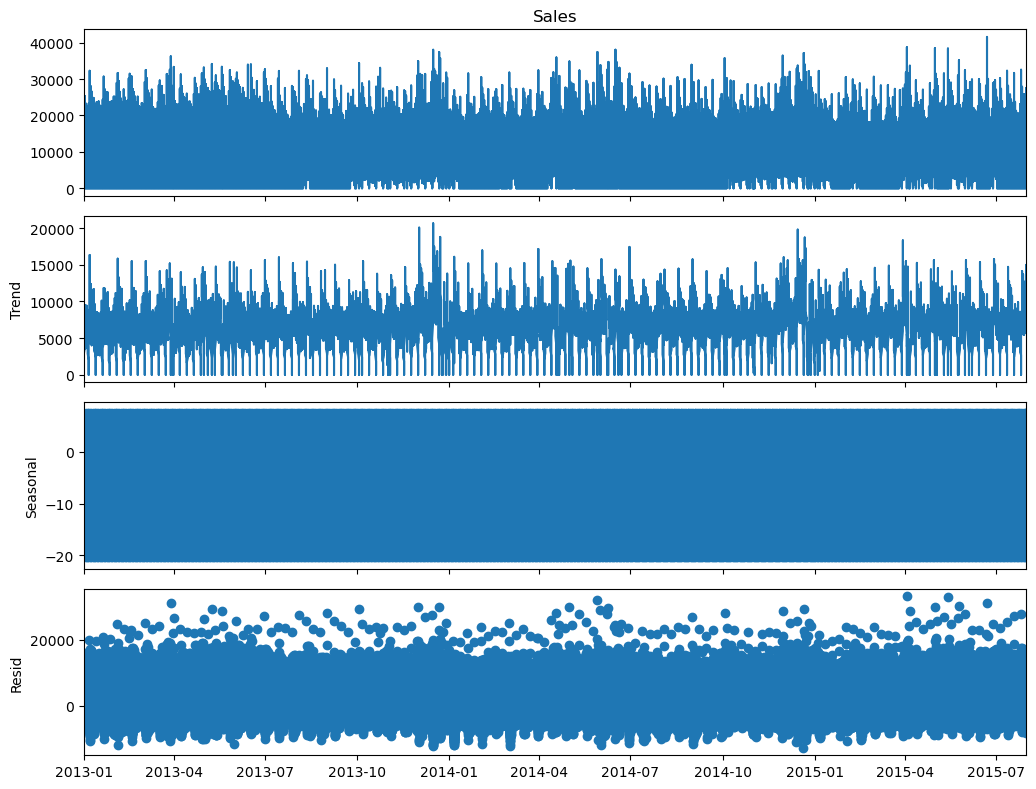

In [509]:
result = seasonal_decompose(df_decomp['Sales'], model = 'additive', period = 7)
fig = plt.figure()  
fig = result.plot()  
fig.set_size_inches(10, 8)

In [523]:
def test_Stationarity(dataset) :
    
    rollingMean = dataset.rolling(12).mean()
    rollingStd = dataset.rolling(12).std()
    
    plt.plot(dataset, color='blue', label = 'Original')
    plt.plot(dataset, color= 'red', label = 'rolling mean')
    plt.plot(dataset, color='green', label = 'rolling std')
    
    plt.legend(loc = 'best')
    plt.title("Rolling mean and rolling standard deviation")
    plt.show()

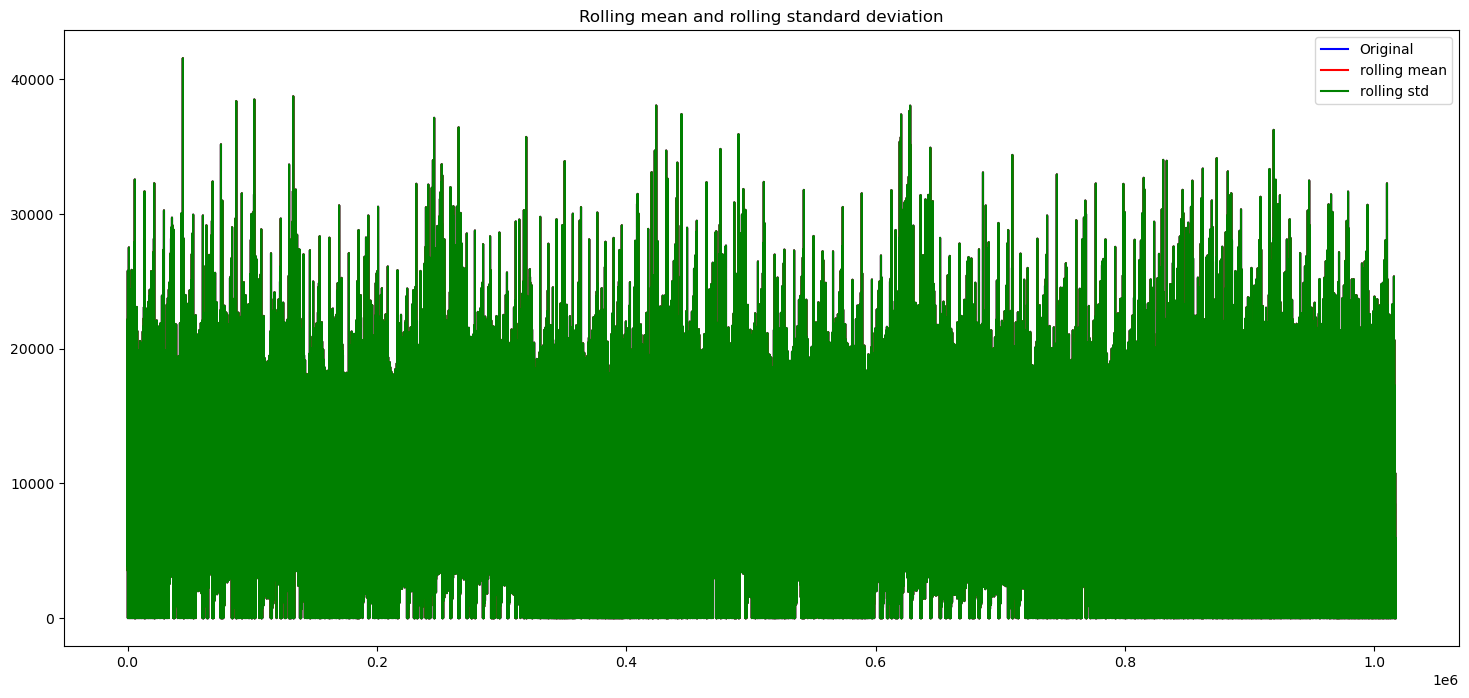

In [525]:
test_Stationarity(df['Sales'])

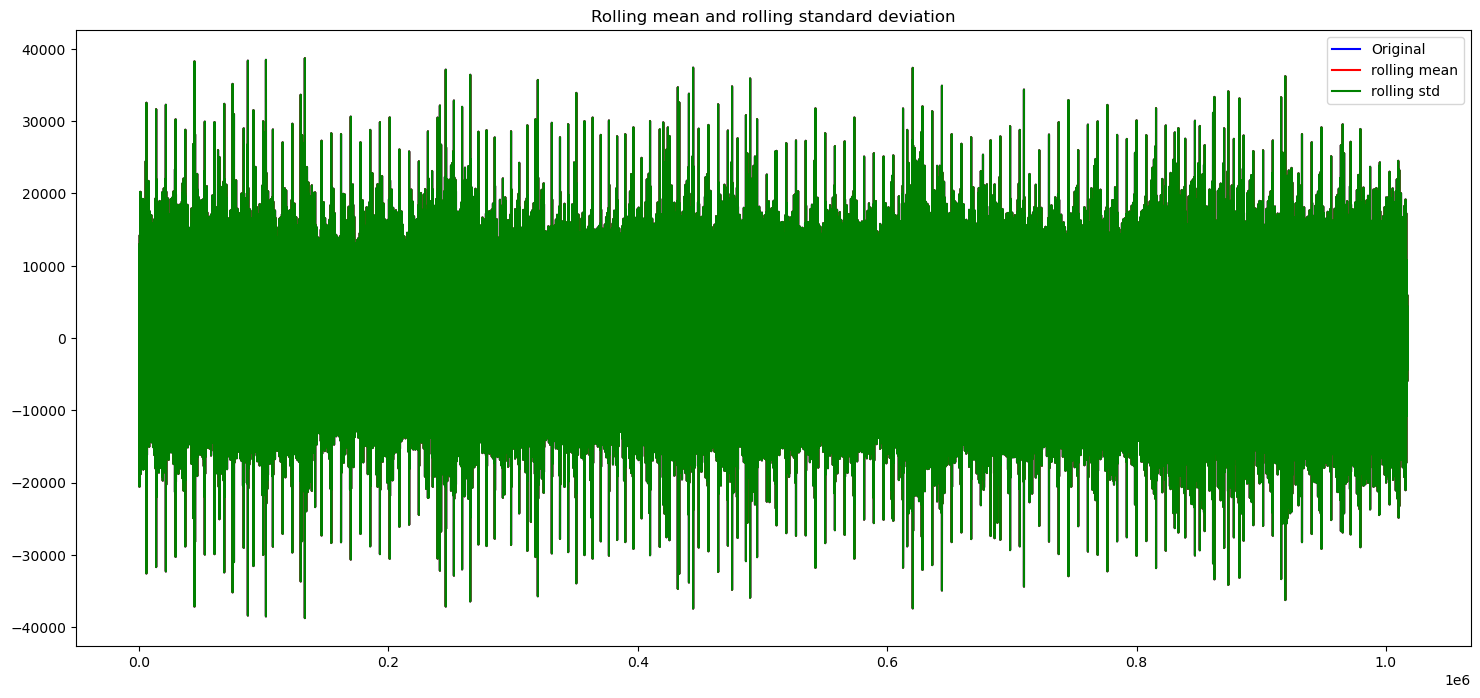

In [557]:
first_diff = df['Sales'] - df['Sales'].shift(1)
first_diff = first_diff.dropna(inplace = False)
test_Stationarity(first_diff)

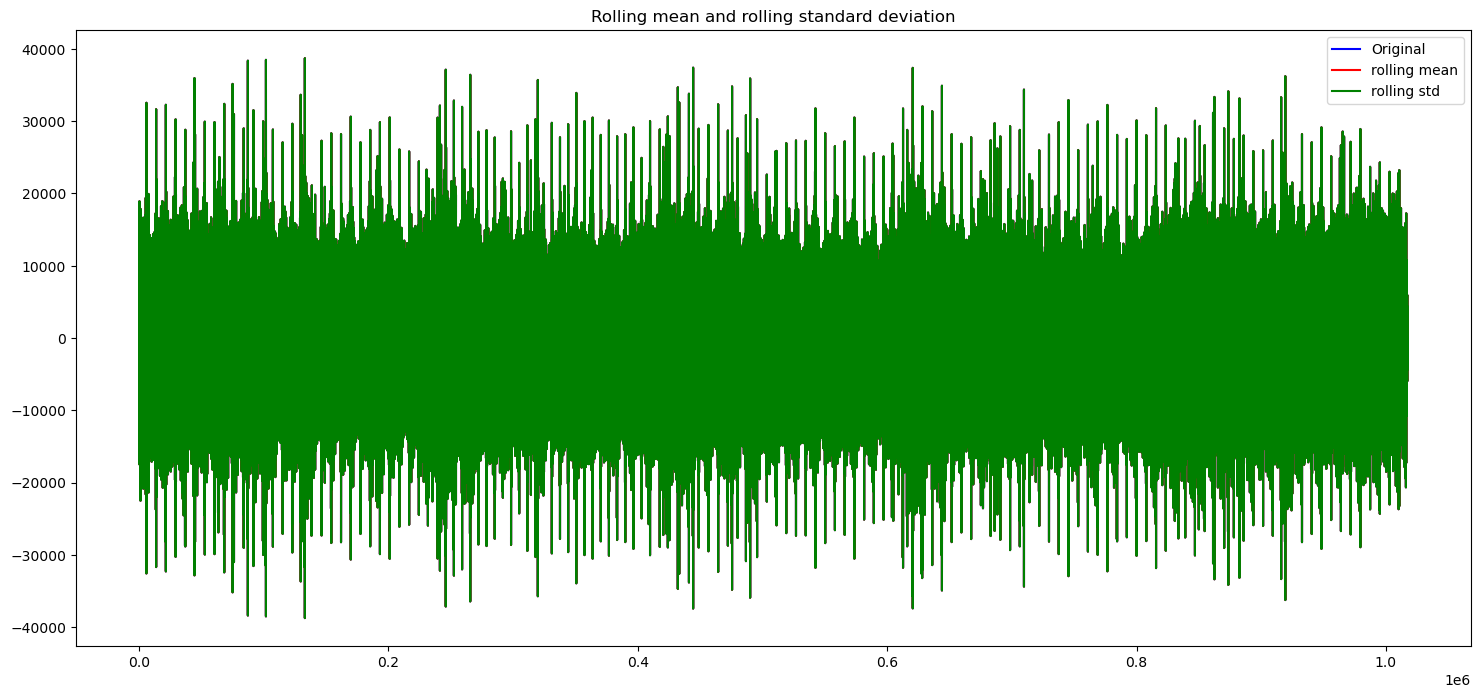

In [559]:
Second_diff = df['Sales'] - df['Sales'].shift(2)
Second_diff = Second_diff.dropna(inplace = False)
test_Stationarity(Second_diff)

### LSTM

In [529]:
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense
#from keras.wrappers.scikit_learn import KerasRegressor

In [533]:
regressor = Sequential()
regressor.add(LSTM(units = 30, return_sequences = True, input_shape = (X_train.shape[1],1)))
regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(LSTM(units = 70, return_sequences = True))
regressor.add(LSTM(units = 50))
regressor.add(Dense(units = 1))

In [537]:
regressor.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [539]:
regressor.fit(X_train, y_train, epochs=20, shuffle = False, batch_size = 64)

Epoch 1/20
11126/11126 ━━━━━━━━━━━━━━━━━━━━ 324s 28ms/step - loss: 46488752.0000
Epoch 2/20
11126/11126 ━━━━━━━━━━━━━━━━━━━━ 327s 29ms/step - loss: 40497428.0000
Epoch 3/20
11126/11126 ━━━━━━━━━━━━━━━━━━━━ 330s 30ms/step - loss: 35151908.0000
Epoch 4/20
11126/11126 ━━━━━━━━━━━━━━━━━━━━ 331s 30ms/step - loss: 30442908.0000
Epoch 5/20
11126/11126 ━━━━━━━━━━━━━━━━━━━━ 334s 30ms/step - loss: 26369176.0000
Epoch 6/20
11126/11126 ━━━━━━━━━━━━━━━━━━━━ 337s 30ms/step - loss: 22929070.0000
Epoch 7/20
11126/11126 ━━━━━━━━━━━━━━━━━━━━ 334s 30ms/step - loss: 20120228.0000
Epoch 8/20
11126/11126 ━━━━━━━━━━━━━━━━━━━━ 345s 31ms/step - loss: 17938486.0000
Epoch 9/20
11126/11126 ━━━━━━━━━━━━━━━━━━━━ 345s 31ms/step - loss: 16376132.0000
Epoch 10/20
11126/11126 ━━━━━━━━━━━━━━━━━━━━ 353s 32ms/step - loss: 15412566.0000
Epoch 11/20
11126/11126 ━━━━━━━━━━━━━━━━━━━━ 342s 31ms/step - loss: 14976991.0000
Epoch 12/20
11126/11126 ━━━━━━━━━━━━━━━━━━━━ 345s 31ms/step - loss: 14867957.0000
Epoch 13/20
11126/11126 ━

In [543]:
y_pred_keras = regressor.predict(X_test)

9537/9537 ━━━━━━━━━━━━━━━━━━━━ 70s 7ms/step


In [545]:
getEvaluationMatrix('Keras CNN', 'Testing', y_test, y_pred_keras)

Evaluation metrics for Keras CNN Testing
MSE : 14750281.06364309
RMSE : 3840.6094651296025
MAE : 2878.1341668767236
R2 : -4.313969175218091e-07
Adjusted R2 : 0.9525811940335708


## Conclusion

After considering different type of refression and time series model, we noticed that linear regression models suit better the other time-series models. Hence, for the given dataset we could use a regression model, rather than a time-series model to forecast sales.

The Random Forest model is the most suitable model. It has the lowest Mean Absolute Error and accuracy around 95%.

#### EDA Conclusions:
 - Sales are highly correlated to number of Customers
 - Promotion leads to increase in Sales and Customers both.
 - Sales are increased during Chirstmas week, this might be due to the fact that people buy more products during a Christmas celebration.
 - The store A has most customers and sales
 - StoreType B has the lowest Average Sales per Customer